<a href="https://colab.research.google.com/github/KV-DHEERAJKUMAR/EfficientNet-B3-Based-Transfer-Learning-Framework-for-Multi-Class-Skin-Lesion-Classification/blob/main/EfficientNet_B3_Based_Transfer_Learning_Framework_for_Multi_Class_Skin_Lesion_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# BLOCK 1: INSTALL ALL NECESSARY LIBRARIES
# HAM10000 + EFFICIENTNET-B3 + GRAD-CAM
# ============================================================

# IMPORTANT:
# In a fresh Google Colab runtime, PyTorch and torchvision are
# normally pre-installed. Do NOT reinstall them unless they are
# actually broken.

!pip install -q kagglehub
!pip install -q grad-cam
!pip install -q scikit-learn
!pip install -q seaborn
!pip install -q opencv-python-headless
!pip install -q pandas
!pip install -q matplotlib
!pip install -q tqdm

print("Required additional libraries installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 69.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Required additional libraries installed successfully!


In [ ]:
# ============================================================
# BLOCK 2: IMPORT ALL NECESSARY LIBRARIES
# ============================================================

# ---------------------------
# BASIC PYTHON LIBRARIES
# ---------------------------

import os
import gc
import copy
import time
import random
import warnings

# ---------------------------
# NUMERICAL AND DATA HANDLING
# ---------------------------

import numpy as np
import pandas as pd

# ---------------------------
# IMAGE PROCESSING
# ---------------------------

import cv2

from PIL import Image

# ---------------------------
# VISUALIZATION
# ---------------------------

import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# PROGRESS BAR
# ---------------------------

from tqdm.auto import tqdm

# ---------------------------
# PYTORCH
# ---------------------------

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision

# ---------------------------
# PYTORCH DATA LOADING
# ---------------------------

from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler
)

# ---------------------------
# IMAGE TRANSFORMS
# ---------------------------

from torchvision import transforms

# ---------------------------
# EFFICIENTNET-B3
# ---------------------------

from torchvision.models import (
    efficientnet_b3,
    EfficientNet_B3_Weights
)

# ---------------------------
# SCIKIT-LEARN
# ---------------------------

from sklearn.model_selection import (
    train_test_split
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

from sklearn.preprocessing import (
    label_binarize
)

# ---------------------------
# KAGGLEHUB
# ---------------------------

import kagglehub

# ---------------------------
# GRAD-CAM
# ---------------------------

from pytorch_grad_cam import (
    GradCAM
)

from pytorch_grad_cam.utils.model_targets import (
    ClassifierOutputTarget
)

from pytorch_grad_cam.utils.image import (
    show_cam_on_image
)

# ---------------------------
# GOOGLE COLAB IMAGE UPLOAD
# ---------------------------

from google.colab import files

# ---------------------------
# REMOVE WARNINGS
# ---------------------------

warnings.filterwarnings("ignore")

print("=" * 70)
print("ALL LIBRARIES IMPORTED SUCCESSFULLY")
print("=" * 70)

print("PyTorch Version     :", torch.__version__)
print("Torchvision Version :", torchvision.__version__)
print("CUDA Available      :", torch.cuda.is_available())

if torch.cuda.is_available():

    print(
        "GPU                 :",
        torch.cuda.get_device_name(0)
    )

ALL LIBRARIES IMPORTED SUCCESSFULLY
PyTorch Version     : 2.11.0+cu128
Torchvision Version : 0.26.0+cu128
CUDA Available      : True
GPU                 : Tesla T4


In [ ]:
# ============================================================
# BLOCK 1: INSTALL REQUIRED LIBRARIES
# ============================================================

!pip install -q kagglehub grad-cam seaborn scikit-learn opencv-python-headless tqdm

print("Additional libraries installed successfully.")

Additional libraries installed successfully.


In [ ]:
# ============================================================
# BLOCK 2: IMPORT LIBRARIES AND CONFIGURATION
# ============================================================

import os
import gc
import copy
import time
import random
import warnings

import numpy as np
import pandas as pd

import cv2

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision

from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler
)

from torchvision import transforms

from torchvision.models import (
    efficientnet_b3,
    EfficientNet_B3_Weights
)

# Scikit-learn
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

from sklearn.preprocessing import label_binarize

# KaggleHub
import kagglehub

warnings.filterwarnings("ignore")

# ============================================================
# CHECK PYTORCH INSTALLATION
# ============================================================

print("=" * 70)
print("ENVIRONMENT CHECK")
print("=" * 70)

print("PyTorch Version     :", torch.__version__)
print("Torchvision Version :", torchvision.__version__)

try:
    import torch._utils
    print("torch._utils        : Available ✓")

except Exception as e:

    print("torch._utils        : ERROR")
    print(e)

    raise RuntimeError(
        "PyTorch installation is corrupted. "
        "Reinstall PyTorch and restart the runtime."
    )

# ============================================================
# DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device              :", DEVICE)

if torch.cuda.is_available():

    print(
        "GPU                 :",
        torch.cuda.get_device_name(0)
    )

# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

# ============================================================
# PAPER HYPERPARAMETERS
# ============================================================

IMG_SIZE = 300

BATCH_SIZE = 32

NUM_EPOCHS = 20

LEARNING_RATE = 0.0001

NUM_CLASSES = 7

# Keep 0 to avoid DataLoader worker issue
NUM_WORKERS = 0

print("\n" + "=" * 70)
print("EXPERIMENTAL CONFIGURATION")
print("=" * 70)

print("Image Size     :", IMG_SIZE, "x", IMG_SIZE)
print("Batch Size     :", BATCH_SIZE)
print("Epochs         :", NUM_EPOCHS)
print("Learning Rate  :", LEARNING_RATE)
print("Optimizer      : Adam")
print("Loss Function  : Cross-Entropy")
print("Number Classes :", NUM_CLASSES)

# ============================================================
# CLASS DEFINITIONS
# ============================================================

CLASS_NAMES = [
    "akiec",
    "bcc",
    "bkl",
    "df",
    "mel",
    "nv",
    "vasc"
]

CLASS_FULL_NAMES = {

    "akiec":
    "Actinic Keratoses / Intraepithelial Carcinoma",

    "bcc":
    "Basal Cell Carcinoma",

    "bkl":
    "Benign Keratosis-like Lesions",

    "df":
    "Dermatofibroma",

    "mel":
    "Melanoma",

    "nv":
    "Melanocytic Nevus",

    "vasc":
    "Vascular Lesions"
}

CLASS_TO_IDX = {

    cls: idx

    for idx, cls in enumerate(CLASS_NAMES)
}

IDX_TO_CLASS = {

    idx: cls

    for cls, idx in CLASS_TO_IDX.items()
}

print("\nClass Mapping")

for idx, cls in enumerate(CLASS_NAMES):

    print(
        f"{idx}: {cls.upper()} - "
        f"{CLASS_FULL_NAMES[cls]}"
    )

ENVIRONMENT CHECK
PyTorch Version     : 2.11.0+cu128
Torchvision Version : 0.26.0+cu128
torch._utils        : Available ✓
Device              : cuda
GPU                 : Tesla T4

EXPERIMENTAL CONFIGURATION
Image Size     : 300 x 300
Batch Size     : 32
Epochs         : 20
Learning Rate  : 0.0001
Optimizer      : Adam
Loss Function  : Cross-Entropy
Number Classes : 7

Class Mapping
0: AKIEC - Actinic Keratoses / Intraepithelial Carcinoma
1: BCC - Basal Cell Carcinoma
2: BKL - Benign Keratosis-like Lesions
3: DF - Dermatofibroma
4: MEL - Melanoma
5: NV - Melanocytic Nevus
6: VASC - Vascular Lesions


In [ ]:
# ============================================================
# BLOCK 3: DOWNLOAD HAM10000 DATASET
# ============================================================

import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "kmader/skin-cancer-mnist-ham10000"
)

print(
    "Path to dataset files:",
    path
)

DATASET_PATH = path

print("\nDataset downloaded / located successfully.")

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000

Dataset downloaded / located successfully.


In [ ]:
# ============================================================
# BLOCK 4: LOAD HAM10000 METADATA AND IMAGE PATHS
# ============================================================

# ============================================================
# FIND METADATA CSV
# ============================================================

metadata_path = None

for root, dirs, files in os.walk(DATASET_PATH):

    if "HAM10000_metadata.csv" in files:

        metadata_path = os.path.join(
            root,
            "HAM10000_metadata.csv"
        )

        break

if metadata_path is None:

    raise FileNotFoundError(
        "HAM10000_metadata.csv was not found."
    )

print(
    "Metadata Path:",
    metadata_path
)

# ============================================================
# LOAD METADATA
# ============================================================

df = pd.read_csv(
    metadata_path
)

print(
    "\nOriginal Metadata Shape:",
    df.shape
)

display(
    df.head()
)

# ============================================================
# FIND ALL IMAGES
# ============================================================

print(
    "\nIndexing HAM10000 images..."
)

image_path_dict = {}

for root, dirs, files in os.walk(
    DATASET_PATH
):

    for filename in files:

        if filename.lower().endswith(
            (
                ".jpg",
                ".jpeg",
                ".png"
            )
        ):

            image_id = os.path.splitext(
                filename
            )[0]

            image_path_dict[
                image_id
            ] = os.path.join(
                root,
                filename
            )

print(
    "Total image files found:",
    len(image_path_dict)
)

# ============================================================
# MAP IMAGE PATH
# ============================================================

df["image_path"] = df[
    "image_id"
].map(
    image_path_dict
)

missing = df[
    "image_path"
].isna().sum()

print(
    "Missing image paths:",
    missing
)

df = df.dropna(
    subset=["image_path"]
).reset_index(
    drop=True
)

# ============================================================
# CREATE NUMERIC LABELS
# ============================================================

df["label"] = df[
    "dx"
].map(
    CLASS_TO_IDX
)

df = df.dropna(
    subset=["label"]
).reset_index(
    drop=True
)

df["label"] = df[
    "label"
].astype(int)

print(
    "\nFinal Dataset Shape:",
    df.shape
)

print(
    "Total Valid Images:",
    len(df)
)

if len(df) == 10015:

    print(
        "✓ All 10,015 HAM10000 images loaded successfully."
    )

# ============================================================
# CLASS DISTRIBUTION
# ============================================================

class_counts = (

    df["dx"]

    .value_counts()

    .reindex(CLASS_NAMES)
)

print("\n" + "=" * 60)
print("HAM10000 CLASS DISTRIBUTION")
print("=" * 60)

for cls in CLASS_NAMES:

    print(
        f"{cls.upper():6s}: "
        f"{class_counts[cls]}"
    )

Metadata Path: /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv

Original Metadata Shape: (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear



Indexing HAM10000 images...
Total image files found: 10015
Missing image paths: 0

Final Dataset Shape: (10015, 9)
Total Valid Images: 10015
✓ All 10,015 HAM10000 images loaded successfully.

HAM10000 CLASS DISTRIBUTION
AKIEC : 327
BCC   : 514
BKL   : 1099
DF    : 115
MEL   : 1113
NV    : 6705
VASC  : 142


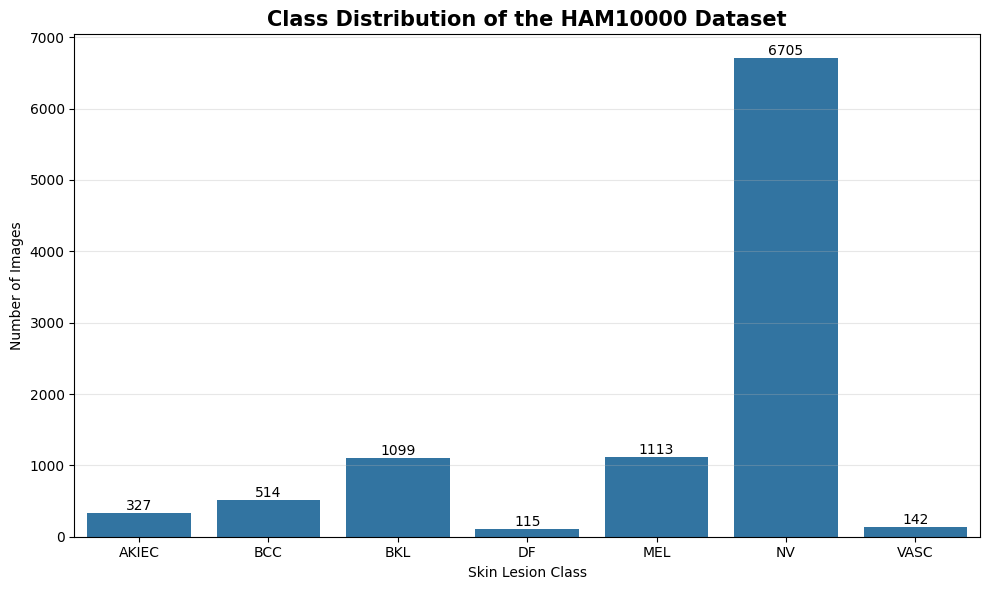

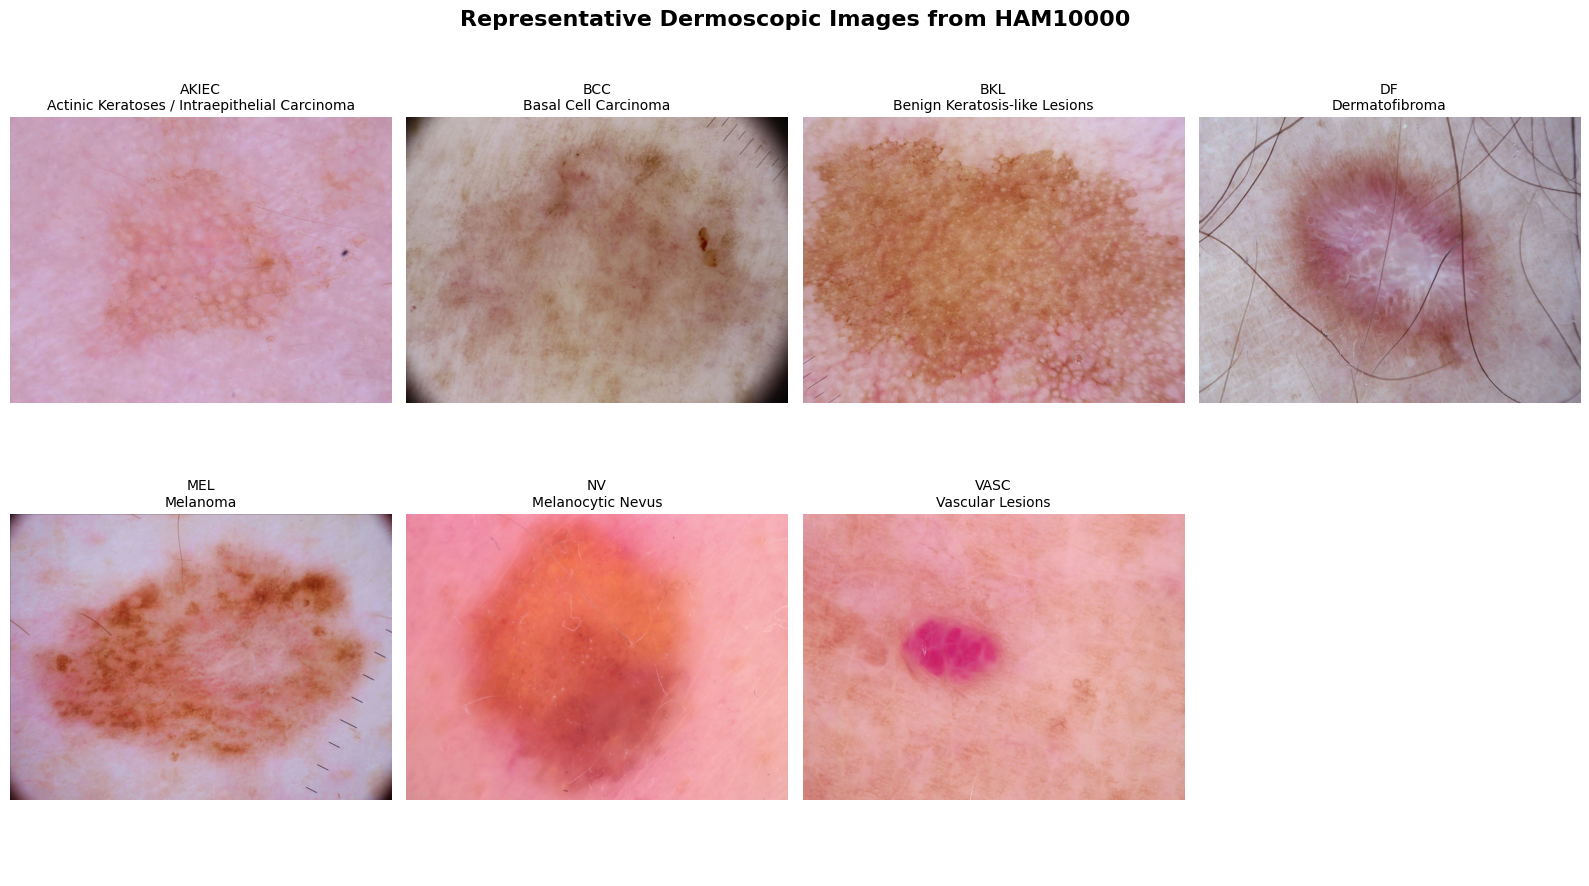

In [ ]:
# ============================================================
# BLOCK 5: DATASET VISUALIZATION
# ============================================================

# ============================================================
# CLASS DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(10, 6)
)

ax = sns.barplot(

    x=[
        cls.upper()
        for cls in CLASS_NAMES
    ],

    y=[
        class_counts[cls]
        for cls in CLASS_NAMES
    ]
)

plt.title(
    "Class Distribution of the HAM10000 Dataset",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Skin Lesion Class"
)

plt.ylabel(
    "Number of Images"
)

plt.grid(
    axis="y",
    alpha=0.3
)

for container in ax.containers:

    ax.bar_label(
        container
    )

plt.tight_layout()

plt.savefig(
    "01_HAM10000_Class_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# SAMPLE IMAGES
# ============================================================

fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 9)
)

axes = axes.flatten()

for i, cls in enumerate(
    CLASS_NAMES
):

    sample = df[
        df["dx"] == cls
    ].sample(
        1,
        random_state=SEED
    ).iloc[0]

    image = Image.open(
        sample["image_path"]
    ).convert("RGB")

    axes[i].imshow(
        image
    )

    axes[i].set_title(
        f"{cls.upper()}\n"
        f"{CLASS_FULL_NAMES[cls]}",
        fontsize=10
    )

    axes[i].axis(
        "off"
    )

axes[-1].axis(
    "off"
)

plt.suptitle(
    "Representative Dermoscopic Images from HAM10000",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "02_HAM10000_Sample_Images.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# BLOCK 6: STRATIFIED 80:20 TRAIN-TEST SPLIT
# ============================================================

train_df, test_df = train_test_split(

    df,

    test_size=0.20,

    random_state=SEED,

    stratify=df["label"]
)

train_df = train_df.reset_index(
    drop=True
)

test_df = test_df.reset_index(
    drop=True
)

print("=" * 70)
print("STRATIFIED DATA SPLIT")
print("=" * 70)

print(
    "Total Images    :",
    len(df)
)

print(
    "Training Images :",
    len(train_df)
)

print(
    "Testing Images  :",
    len(test_df)
)

print(
    "Training Ratio  :",
    f"{100 * len(train_df)/len(df):.2f}%"
)

print(
    "Testing Ratio   :",
    f"{100 * len(test_df)/len(df):.2f}%"
)

# ============================================================
# CLASS-WISE SPLIT
# ============================================================

split_table = pd.DataFrame({

    "Total":

    df["dx"]
    .value_counts()
    .reindex(CLASS_NAMES),

    "Training":

    train_df["dx"]
    .value_counts()
    .reindex(CLASS_NAMES),

    "Testing":

    test_df["dx"]
    .value_counts()
    .reindex(CLASS_NAMES)
})

split_table.index = [

    cls.upper()

    for cls in split_table.index
]

display(
    split_table
)

STRATIFIED DATA SPLIT
Total Images    : 10015
Training Images : 8012
Testing Images  : 2003
Training Ratio  : 80.00%
Testing Ratio   : 20.00%


,Total,Training,Testing
AKIEC,327,262,65
BCC,514,411,103
BKL,1099,879,220
DF,115,92,23
MEL,1113,890,223
NV,6705,5364,1341
VASC,142,114,28


In [ ]:
# ============================================================
# BLOCK 7: PREPROCESSING AND DATA AUGMENTATION
# ============================================================

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]

# ============================================================
# TRAINING TRANSFORMS
#
# Paper:
# Resize 300x300
# Horizontal Flip
# Rotation +/-20 degrees
# ImageNet Normalization
# ============================================================

train_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=20
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

# ============================================================
# TEST TRANSFORM
# ============================================================

test_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ============================================================
# CUSTOM DATASET
# ============================================================

class HAM10000Dataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.dataframe = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

    def __len__(
        self
    ):

        return len(
            self.dataframe
        )

    def __getitem__(
        self,
        index
    ):

        row = self.dataframe.iloc[
            index
        ]

        image = Image.open(
            row["image_path"]
        ).convert(
            "RGB"
        )

        label = int(
            row["label"]
        )

        if self.transform:

            image = self.transform(
                image
            )

        return image, label


# ============================================================
# CREATE DATASETS
# ============================================================

train_dataset = HAM10000Dataset(

    train_df,

    transform=train_transform
)

test_dataset = HAM10000Dataset(

    test_df,

    transform=test_transform
)

print(
    "Training Dataset:",
    len(train_dataset)
)

print(
    "Testing Dataset:",
    len(test_dataset)
)

Training Dataset: 8012
Testing Dataset: 2003


In [ ]:
# ============================================================
# BLOCK 8: UPDATED CLASS IMBALANCE HANDLING + DATA LOADERS
# HAM10000
#
# Strategy:
# - Remove aggressive WeightedRandomSampler
# - Use normal shuffled training batches
# - Calculate moderate sqrt inverse-frequency class weights
# - Pass these weights to CrossEntropyLoss in Block 9
# ============================================================

import numpy as np
import torch

from torch.utils.data import DataLoader


# ============================================================
# 1. GET TRAINING LABELS
# ============================================================

train_labels = train_df[
    "label"
].values.astype(int)


# ============================================================
# 2. COUNT TRAINING SAMPLES FOR EACH CLASS
# ============================================================

class_counts_train = np.bincount(
    train_labels,
    minlength=NUM_CLASSES
)

print("=" * 65)
print("TRAINING CLASS DISTRIBUTION")
print("=" * 65)

for i, count in enumerate(class_counts_train):

    print(
        f"{CLASS_NAMES[i].upper():6s}: "
        f"{count}"
    )

print("-" * 65)

print(
    "Total Training Images:",
    len(train_labels)
)


# ============================================================
# 3. CALCULATE MODERATE CLASS WEIGHTS
#
# We use square-root inverse frequency instead of direct
# inverse frequency.
#
# This reduces excessive weighting of very small classes
# such as DF and VASC.
# ============================================================

class_weights = np.sqrt(

    len(train_labels) /

    (
        NUM_CLASSES
        * class_counts_train.astype(np.float64)
    )
)


# ============================================================
# 4. NORMALIZE CLASS WEIGHTS
#
# Mean weight = approximately 1
# ============================================================

class_weights = (

    class_weights /

    class_weights.mean()
)


# ============================================================
# 5. DISPLAY CLASS WEIGHTS
# ============================================================

print("\n" + "=" * 65)
print("MODERATE CLASS WEIGHTS")
print("=" * 65)

for i, weight in enumerate(class_weights):

    print(
        f"{CLASS_NAMES[i].upper():6s}: "
        f"{weight:.4f}"
    )


# ============================================================
# 6. CONVERT CLASS WEIGHTS TO PYTORCH TENSOR
#
# This tensor will be used in CrossEntropyLoss.
# ============================================================

class_weights_tensor = torch.tensor(

    class_weights,

    dtype=torch.float32

).to(
    DEVICE
)

print(
    "\nClass Weight Tensor:"
)

print(
    class_weights_tensor
)


# ============================================================
# 7. CREATE TRAINING DATA LOADER
#
# IMPORTANT:
#
# WeightedRandomSampler is NOT used here.
#
# shuffle=True allows normal random batch generation.
#
# num_workers=0 is retained because your environment
# previously produced the torch._utils DataLoader worker error.
# ============================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=0,

    pin_memory=torch.cuda.is_available(),

    drop_last=False
)


# ============================================================
# 8. CREATE TEST / VALIDATION DATA LOADER
# ============================================================

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=torch.cuda.is_available(),

    drop_last=False
)


# ============================================================
# 9. DISPLAY DATALOADER INFORMATION
# ============================================================

print("\n" + "=" * 65)
print("DATA LOADER INFORMATION")
print("=" * 65)

print(
    "Training Images :",
    len(train_dataset)
)

print(
    "Testing Images  :",
    len(test_dataset)
)

print(
    "Batch Size      :",
    BATCH_SIZE
)

print(
    "Training Batches:",
    len(train_loader)
)

print(
    "Testing Batches :",
    len(test_loader)
)

print(
    "Training Shuffle: True"
)

print(
    "Weighted Sampler: Disabled"
)


# ============================================================
# 10. VERIFY FIRST TRAINING BATCH
# ============================================================

print(
    "\nLoading first training batch..."
)

try:

    sample_images, sample_labels = next(
        iter(train_loader)
    )

    print(
        "\n✓ First training batch loaded successfully."
    )

    print(
        "Image Batch Shape:",
        sample_images.shape
    )

    print(
        "Label Batch Shape:",
        sample_labels.shape
    )

    print(
        "Image Data Type:",
        sample_images.dtype
    )

    print(
        "Label Data Type:",
        sample_labels.dtype
    )

    print(
        "Labels:",
        sample_labels.tolist()
    )

except Exception as e:

    print(
        "\nError loading training batch:"
    )

    print(e)

    raise


# ============================================================
# 11. CHECK CLASS DISTRIBUTION IN FIRST BATCH
# ============================================================

unique_labels, batch_counts = torch.unique(

    sample_labels,

    return_counts=True
)

print(
    "\nFirst Batch Class Distribution:"
)

for label, count in zip(

    unique_labels.tolist(),

    batch_counts.tolist()
):

    print(

        f"{CLASS_NAMES[label].upper():6s}: "

        f"{count}"
    )


# ============================================================
# FINAL STATUS
# ============================================================

print("\n" + "=" * 65)
print("BLOCK 8 COMPLETED SUCCESSFULLY")
print("=" * 65)

print(
    "\nClass imbalance strategy:"
)

print(
    "✓ Normal shuffled training batches"
)

print(
    "✓ Moderate sqrt inverse-frequency class weights"
)

print(
    "✓ No aggressive oversampling"
)

print(
    "✓ Class weights ready for CrossEntropyLoss"
)

TRAINING CLASS DISTRIBUTION
AKIEC : 262
BCC   : 411
BKL   : 879
DF    : 92
MEL   : 890
NV    : 5364
VASC  : 114
-----------------------------------------------------------------
Total Training Images: 8012

MODERATE CLASS WEIGHTS
AKIEC : 1.1091
BCC   : 0.8855
BKL   : 0.6055
DF    : 1.8716
MEL   : 0.6018
NV    : 0.2451
VASC  : 1.6814

Class Weight Tensor:
tensor([1.1091, 0.8855, 0.6055, 1.8716, 0.6018, 0.2451, 1.6814],
       device='cuda:0')

DATA LOADER INFORMATION
Training Images : 8012
Testing Images  : 2003
Batch Size      : 32
Training Batches: 251
Testing Batches : 63
Training Shuffle: True
Weighted Sampler: Disabled

Loading first training batch...

✓ First training batch loaded successfully.
Image Batch Shape: torch.Size([32, 3, 300, 300])
Label Batch Shape: torch.Size([32])
Image Data Type: torch.float32
Label Data Type: torch.int64
Labels: [5, 5, 5, 5, 5, 5, 5, 5, 5, 0, 0, 5, 2, 5, 5, 0, 1, 2, 5, 5, 5, 5, 5, 5, 5, 5, 5, 2, 5, 5, 5, 5]

First Batch Class Distribution:
AKIEC : 

In [ ]:
# ============================================================
# BLOCK 9: UPDATED EFFICIENTNET-B3 TRANSFER LEARNING MODEL
# HAM10000 - 7 CLASS SKIN LESION CLASSIFICATION
#
# IMPORTANT:
# Run Updated Block 8 before running this block.
# class_weights_tensor must already be created.
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision.models import (
    efficientnet_b3,
    EfficientNet_B3_Weights
)


# ============================================================
# 1. DISPLAY MODEL INITIALIZATION
# ============================================================

print("=" * 70)
print("INITIALIZING EFFICIENTNET-B3 TRANSFER LEARNING MODEL")
print("=" * 70)

print(
    "Device:",
    DEVICE
)


# ============================================================
# 2. VERIFY CLASS WEIGHTS FROM BLOCK 8
# ============================================================

if "class_weights_tensor" not in globals():

    raise RuntimeError(
        "class_weights_tensor was not found. "
        "Please run the updated Block 8 first."
    )

print(
    "\nClass weights loaded successfully from Block 8."
)

print(
    "Class Weights:",
    class_weights_tensor
)


# ============================================================
# 3. LOAD IMAGENET PRETRAINED EFFICIENTNET-B3
# ============================================================

print(
    "\nLoading ImageNet-pretrained EfficientNet-B3..."
)

weights = EfficientNet_B3_Weights.DEFAULT

model = efficientnet_b3(
    weights=weights
)

print(
    "✓ EfficientNet-B3 loaded successfully."
)


# ============================================================
# 4. GET ORIGINAL CLASSIFIER INPUT FEATURES
#
# EfficientNet-B3 classifier:
# Dropout -> Linear
#
# Linear layer input features = 1536
# ============================================================

num_features = model.classifier[1].in_features

print(
    "\nClassifier Input Features:",
    num_features
)


# ============================================================
# 5. REPLACE IMAGENET CLASSIFICATION HEAD
#
# Original:
# 1000 ImageNet classes
#
# New:
# 7 HAM10000 skin lesion classes
# ============================================================

model.classifier = nn.Sequential(

    nn.Dropout(
        p=0.3
    ),

    nn.Linear(
        in_features=num_features,
        out_features=NUM_CLASSES
    )
)


# ============================================================
# 6. MOVE MODEL TO GPU / CPU
# ============================================================

model = model.to(
    DEVICE
)

print(
    "\n✓ Model moved to:",
    DEVICE
)


# ============================================================
# 7. WEIGHTED CROSS-ENTROPY LOSS
#
# IMPORTANT:
# Updated Block 8 removed WeightedRandomSampler.
#
# Class imbalance is now handled using moderate
# sqrt inverse-frequency weights calculated in Block 8.
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

print(
    "\n✓ Weighted CrossEntropyLoss initialized."
)


# ============================================================
# 8. ADAM OPTIMIZER
#
# Paper configuration:
# Optimizer     : Adam
# Learning Rate : 0.0001
# ============================================================

optimizer = optim.Adam(

    model.parameters(),

    lr=LEARNING_RATE
)


# ============================================================
# 9. OPTIONAL LEARNING RATE SCHEDULER
#
# ReduceLROnPlateau automatically lowers the learning rate
# when validation loss stops improving.
#
# This does not change the EfficientNet-B3 architecture.
# ============================================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.5,

    patience=3,

    min_lr=1e-7
)


# ============================================================
# 10. DISPLAY COMPLETE MODEL CONFIGURATION
# ============================================================

print("\n" + "=" * 70)
print("MODEL CONFIGURATION")
print("=" * 70)

print(
    "Architecture       : EfficientNet-B3"
)

print(
    "Pretrained Weights : ImageNet"
)

print(
    "Input Resolution   :",
    f"{IMG_SIZE} x {IMG_SIZE}"
)

print(
    "Output Classes     :",
    NUM_CLASSES
)

print(
    "Classifier Features:",
    num_features
)

print(
    "Dropout            : 0.3"
)

print(
    "Loss Function      : Weighted CrossEntropyLoss"
)

print(
    "Class Balancing    : Moderate sqrt inverse-frequency weights"
)

print(
    "Optimizer          : Adam"
)

print(
    "Initial LR         :",
    LEARNING_RATE
)

print(
    "LR Scheduler       : ReduceLROnPlateau"
)

print(
    "Batch Size         :",
    BATCH_SIZE
)

print(
    "Training Epochs    :",
    NUM_EPOCHS
)


# ============================================================
# 11. DISPLAY NEW CLASSIFICATION HEAD
# ============================================================

print("\n" + "=" * 70)
print("NEW EFFICIENTNET-B3 CLASSIFICATION HEAD")
print("=" * 70)

print(
    model.classifier
)


# ============================================================
# 12. DISPLAY TRAINABLE PARAMETERS
# ============================================================

total_params = sum(

    p.numel()

    for p in model.parameters()
)

trainable_params = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad
)

print("\n" + "=" * 70)
print("MODEL PARAMETERS")
print("=" * 70)

print(
    f"Total Parameters     : {total_params:,}"
)

print(
    f"Trainable Parameters : {trainable_params:,}"
)


# ============================================================
# 13. VERIFY MODEL WITH DUMMY INPUT
# ============================================================

print("\n" + "=" * 70)
print("TESTING MODEL FORWARD PASS")
print("=" * 70)

dummy_input = torch.randn(

    2,
    3,
    IMG_SIZE,
    IMG_SIZE

).to(
    DEVICE
)

model.eval()

with torch.no_grad():

    dummy_output = model(
        dummy_input
    )

print(
    "Dummy Input Shape :",
    dummy_input.shape
)

print(
    "Model Output Shape:",
    dummy_output.shape
)


# ============================================================
# 14. VERIFY OUTPUT DIMENSION
# ============================================================

expected_shape = (
    2,
    NUM_CLASSES
)

assert dummy_output.shape == expected_shape, (

    f"Expected output shape {expected_shape}, "
    f"but received {dummy_output.shape}"
)

print(
    "\n✓ Model output dimension is correct."
)


# ============================================================
# 15. CLEAN GPU MEMORY
# ============================================================

del dummy_input
del dummy_output

if torch.cuda.is_available():

    torch.cuda.empty_cache()


# ============================================================
# 16. RESET MODEL TO TRAINING MODE
# ============================================================

model.train()


# ============================================================
# FINAL STATUS
# ============================================================

print("\n" + "=" * 70)
print("BLOCK 9 COMPLETED SUCCESSFULLY")
print("=" * 70)

print(
    "\n✓ ImageNet-pretrained EfficientNet-B3 initialized"
)

print(
    "✓ 7-class HAM10000 classifier initialized"
)

print(
    "✓ Moderate class-weighted CrossEntropyLoss initialized"
)

print(
    "✓ Adam optimizer initialized"
)

print(
    "✓ ReduceLROnPlateau scheduler initialized"
)

print(
    "\nModel is ready for training."
)

INITIALIZING EFFICIENTNET-B3 TRANSFER LEARNING MODEL
Device: cuda

Class weights loaded successfully from Block 8.
Class Weights: tensor([1.1091, 0.8855, 0.6055, 1.8716, 0.6018, 0.2451, 1.6814],
       device='cuda:0')

Loading ImageNet-pretrained EfficientNet-B3...
✓ EfficientNet-B3 loaded successfully.

Classifier Input Features: 1536

✓ Model moved to: cuda

✓ Weighted CrossEntropyLoss initialized.

MODEL CONFIGURATION
Architecture       : EfficientNet-B3
Pretrained Weights : ImageNet
Input Resolution   : 300 x 300
Output Classes     : 7
Classifier Features: 1536
Dropout            : 0.3
Loss Function      : Weighted CrossEntropyLoss
Class Balancing    : Moderate sqrt inverse-frequency weights
Optimizer          : Adam
Initial LR         : 0.0001
LR Scheduler       : ReduceLROnPlateau
Batch Size         : 32
Training Epochs    : 20

NEW EFFICIENTNET-B3 CLASSIFICATION HEAD
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1536, out_features=7, bias=True)
)

M

In [ ]:
# ============================================================
# BLOCK 10: UPDATED EFFICIENTNET-B3 TRAINING
# HAM10000 - 7 CLASS SKIN LESION CLASSIFICATION
#
# Requires:
# - Updated Block 8
# - Updated Block 9
#
# Features:
# - Weighted CrossEntropyLoss from Block 9
# - Adam optimizer
# - ReduceLROnPlateau scheduler
# - Automatic Mixed Precision (AMP) on CUDA
# - Best model checkpoint saving
# - Training/validation loss tracking
# - Training/validation accuracy tracking
# - Learning rate tracking
# ============================================================

import time
import copy
import torch
import numpy as np

from tqdm.auto import tqdm


# ============================================================
# 1. VERIFY REQUIRED OBJECTS
# ============================================================

required_objects = [
    "model",
    "criterion",
    "optimizer",
    "scheduler",
    "train_loader",
    "test_loader"
]

for obj_name in required_objects:

    if obj_name not in globals():

        raise RuntimeError(
            f"{obj_name} was not found. "
            "Please run Blocks 8 and 9 before Block 10."
        )


# ============================================================
# 2. INITIALIZE TRAINING HISTORY
# ============================================================

history = {

    "train_loss": [],

    "train_accuracy": [],

    "val_loss": [],

    "val_accuracy": [],

    "learning_rate": []
}


# ============================================================
# 3. BEST MODEL TRACKING
# ============================================================

best_val_accuracy = 0.0

best_val_loss = float("inf")

best_epoch = 0

best_model_weights = copy.deepcopy(
    model.state_dict()
)

BEST_MODEL_PATH = (
    "best_efficientnet_b3_ham10000.pth"
)


# ============================================================
# 4. AUTOMATIC MIXED PRECISION
#
# AMP is enabled only when CUDA GPU is available.
# This reduces GPU memory usage and can speed up training.
# ============================================================

USE_AMP = torch.cuda.is_available()

if USE_AMP:

    scaler = torch.amp.GradScaler(
        "cuda"
    )

else:

    scaler = None


print("=" * 75)
print("STARTING EFFICIENTNET-B3 TRAINING")
print("=" * 75)

print(
    "Device             :",
    DEVICE
)

print(
    "Number of Epochs   :",
    NUM_EPOCHS
)

print(
    "Batch Size         :",
    BATCH_SIZE
)

print(
    "Initial LR         :",
    LEARNING_RATE
)

print(
    "Optimizer          : Adam"
)

print(
    "Loss Function      : Weighted CrossEntropyLoss"
)

print(
    "LR Scheduler       : ReduceLROnPlateau"
)

print(
    "Mixed Precision    :",
    USE_AMP
)

print(
    "Best Model Path    :",
    BEST_MODEL_PATH
)


# ============================================================
# 5. START TRAINING TIMER
# ============================================================

training_start_time = time.time()


# ============================================================
# 6. TRAINING LOOP
# ============================================================

for epoch in range(NUM_EPOCHS):

    epoch_start_time = time.time()

    print("\n" + "=" * 75)

    print(
        f"EPOCH {epoch + 1}/{NUM_EPOCHS}"
    )

    print("=" * 75)


    # ========================================================
    # TRAINING PHASE
    # ========================================================

    model.train()

    train_running_loss = 0.0

    train_correct = 0

    train_total = 0


    train_progress = tqdm(

        train_loader,

        desc=(
            f"Training "
            f"{epoch + 1}/{NUM_EPOCHS}"
        ),

        leave=True
    )


    for images, labels in train_progress:

        # ====================================================
        # MOVE DATA TO DEVICE
        # ====================================================

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )


        # ====================================================
        # RESET GRADIENTS
        # ====================================================

        optimizer.zero_grad(
            set_to_none=True
        )


        # ====================================================
        # CUDA + AMP TRAINING
        # ====================================================

        if USE_AMP:

            with torch.amp.autocast(
                device_type="cuda"
            ):

                outputs = model(
                    images
                )

                loss = criterion(
                    outputs,
                    labels
                )


            # Backpropagation with GradScaler

            scaler.scale(
                loss
            ).backward()


            # Optimizer step

            scaler.step(
                optimizer
            )


            # Update scaler

            scaler.update()


        # ====================================================
        # CPU TRAINING
        # ====================================================

        else:

            outputs = model(
                images
            )

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()


        # ====================================================
        # CALCULATE TRAINING STATISTICS
        # ====================================================

        batch_size_current = (
            labels.size(0)
        )

        train_running_loss += (

            loss.item()

            * batch_size_current
        )


        predictions = torch.argmax(

            outputs,

            dim=1
        )


        train_correct += (

            predictions == labels

        ).sum().item()


        train_total += (

            batch_size_current
        )


        # ====================================================
        # RUNNING ACCURACY
        # ====================================================

        running_accuracy = (

            100.0

            * train_correct

            / train_total
        )


        # ====================================================
        # UPDATE PROGRESS BAR
        # ====================================================

        train_progress.set_postfix({

            "loss":

            f"{loss.item():.4f}",

            "acc":

            f"{running_accuracy:.2f}%"
        })


    # ========================================================
    # FINAL TRAINING METRICS FOR EPOCH
    # ========================================================

    train_epoch_loss = (

        train_running_loss

        / train_total
    )


    train_epoch_accuracy = (

        train_correct

        / train_total
    )


    # ========================================================
    # VALIDATION PHASE
    # ========================================================

    model.eval()

    val_running_loss = 0.0

    val_correct = 0

    val_total = 0


    val_progress = tqdm(

        test_loader,

        desc=(
            f"Validation "
            f"{epoch + 1}/{NUM_EPOCHS}"
        ),

        leave=False
    )


    with torch.no_grad():

        for images, labels in val_progress:

            # ================================================
            # MOVE DATA TO DEVICE
            # ================================================

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True
            )


            # ================================================
            # FORWARD PASS
            # ================================================

            if USE_AMP:

                with torch.amp.autocast(
                    device_type="cuda"
                ):

                    outputs = model(
                        images
                    )

                    loss = criterion(
                        outputs,
                        labels
                    )

            else:

                outputs = model(
                    images
                )

                loss = criterion(
                    outputs,
                    labels
                )


            # ================================================
            # VALIDATION STATISTICS
            # ================================================

            batch_size_current = (
                labels.size(0)
            )


            val_running_loss += (

                loss.item()

                * batch_size_current
            )


            predictions = torch.argmax(

                outputs,

                dim=1
            )


            val_correct += (

                predictions == labels

            ).sum().item()


            val_total += (

                batch_size_current
            )


    # ========================================================
    # FINAL VALIDATION METRICS
    # ========================================================

    val_epoch_loss = (

        val_running_loss

        / val_total
    )


    val_epoch_accuracy = (

        val_correct

        / val_total
    )


    # ========================================================
    # UPDATE LEARNING RATE SCHEDULER
    #
    # Reduce LR when validation loss stops improving.
    # ========================================================

    scheduler.step(
        val_epoch_loss
    )


    # ========================================================
    # GET CURRENT LEARNING RATE
    # ========================================================

    current_lr = (

        optimizer
        .param_groups[0]
        ["lr"]
    )


    # ========================================================
    # STORE TRAINING HISTORY
    # ========================================================

    history[
        "train_loss"
    ].append(
        train_epoch_loss
    )


    history[
        "train_accuracy"
    ].append(
        train_epoch_accuracy
    )


    history[
        "val_loss"
    ].append(
        val_epoch_loss
    )


    history[
        "val_accuracy"
    ].append(
        val_epoch_accuracy
    )


    history[
        "learning_rate"
    ].append(
        current_lr
    )


    # ========================================================
    # EPOCH TIME
    # ========================================================

    epoch_time = (

        time.time()

        - epoch_start_time
    )


    # ========================================================
    # DISPLAY EPOCH RESULTS
    # ========================================================

    print("\n" + "-" * 75)

    print(
        f"Epoch {epoch + 1} Results"
    )

    print("-" * 75)


    print(
        f"Training Loss       : "
        f"{train_epoch_loss:.4f}"
    )


    print(
        f"Training Accuracy   : "
        f"{train_epoch_accuracy * 100:.2f}%"
    )


    print(
        f"Validation Loss     : "
        f"{val_epoch_loss:.4f}"
    )


    print(
        f"Validation Accuracy : "
        f"{val_epoch_accuracy * 100:.2f}%"
    )


    print(
        f"Learning Rate       : "
        f"{current_lr:.8f}"
    )


    print(
        f"Epoch Time          : "
        f"{epoch_time / 60:.2f} minutes"
    )


    # ========================================================
    # SAVE BEST MODEL
    #
    # Best model is selected using validation accuracy.
    # ========================================================

    if val_epoch_accuracy > best_val_accuracy:

        best_val_accuracy = (
            val_epoch_accuracy
        )

        best_val_loss = (
            val_epoch_loss
        )

        best_epoch = (
            epoch + 1
        )


        best_model_weights = copy.deepcopy(

            model.state_dict()
        )


        torch.save(

            {

                "epoch":
                best_epoch,

                "model_state_dict":
                model.state_dict(),

                "optimizer_state_dict":
                optimizer.state_dict(),

                "val_accuracy":
                best_val_accuracy,

                "val_loss":
                best_val_loss,

                "class_names":
                CLASS_NAMES,

                "image_size":
                IMG_SIZE

            },

            BEST_MODEL_PATH
        )


        print(
            "\n✓ NEW BEST MODEL SAVED"
        )

        print(
            f"  Epoch              : "
            f"{best_epoch}"
        )

        print(
            f"  Validation Accuracy: "
            f"{best_val_accuracy * 100:.2f}%"
        )

        print(
            f"  Validation Loss    : "
            f"{best_val_loss:.4f}"
        )


    else:

        print(
            "\nNo improvement in "
            "validation accuracy."
        )


    # ========================================================
    # GPU MEMORY CLEANUP
    # ========================================================

    if torch.cuda.is_available():

        torch.cuda.empty_cache()


# ============================================================
# 7. TRAINING COMPLETED
# ============================================================

total_training_time = (

    time.time()

    - training_start_time
)


print("\n" + "=" * 75)
print("TRAINING COMPLETED")
print("=" * 75)


print(
    f"Total Training Time : "
    f"{total_training_time / 60:.2f} minutes"
)


print(
    f"Best Epoch          : "
    f"{best_epoch}"
)


print(
    f"Best Val Accuracy   : "
    f"{best_val_accuracy * 100:.2f}%"
)


print(
    f"Best Val Loss       : "
    f"{best_val_loss:.4f}"
)


# ============================================================
# 8. RESTORE BEST MODEL WEIGHTS
#
# This ensures all subsequent evaluation uses the best
# validation-performing model rather than the final epoch.
# ============================================================

model.load_state_dict(

    best_model_weights
)

model = model.to(
    DEVICE
)

model.eval()


print(
    "\n✓ Best EfficientNet-B3 model restored."
)


# ============================================================
# 9. DISPLAY EPOCH-WISE SUMMARY
# ============================================================

print("\n" + "=" * 95)

print(
    f"{'Epoch':<8}"
    f"{'Train Loss':<15}"
    f"{'Train Acc':<15}"
    f"{'Val Loss':<15}"
    f"{'Val Acc':<15}"
    f"{'Learning Rate':<15}"
)

print("=" * 95)


for i in range(
    len(history["train_loss"])
):

    print(

        f"{i + 1:<8}"

        f"{history['train_loss'][i]:<15.4f}"

        f"{history['train_accuracy'][i] * 100:<15.2f}"

        f"{history['val_loss'][i]:<15.4f}"

        f"{history['val_accuracy'][i] * 100:<15.2f}"

        f"{history['learning_rate'][i]:<15.8f}"
    )


print("=" * 95)


# ============================================================
# 10. FINAL STATUS
# ============================================================

print("\n✓ Weighted CrossEntropyLoss used")
print("✓ Adam optimizer used")
print("✓ ReduceLROnPlateau scheduler used")
print("✓ Best model checkpoint saved")
print("✓ Best model weights restored")
print("✓ Training history stored")

print(
    "\nYou can now run Block 11 "
    "to generate training and validation graphs."
)

STARTING EFFICIENTNET-B3 TRAINING
Device             : cuda
Number of Epochs   : 20
Batch Size         : 32
Initial LR         : 0.0001
Optimizer          : Adam
Loss Function      : Weighted CrossEntropyLoss
LR Scheduler       : ReduceLROnPlateau
Mixed Precision    : True
Best Model Path    : best_efficientnet_b3_ham10000.pth

EPOCH 1/20


Training 1/20:   0%|          | 0/251 [00:00<?, ?it/s]

Validation 1/20:   0%|          | 0/63 [00:00<?, ?it/s]


---------------------------------------------------------------------------
Epoch 1 Results
---------------------------------------------------------------------------
Training Loss       : 1.1406
Training Accuracy   : 71.97%
Validation Loss     : 0.6954
Validation Accuracy : 81.03%
Learning Rate       : 0.00010000
Epoch Time          : 3.57 minutes

✓ NEW BEST MODEL SAVED
  Epoch              : 1
  Validation Accuracy: 81.03%
  Validation Loss    : 0.6954

EPOCH 2/20


Training 2/20:   0%|          | 0/251 [00:00<?, ?it/s]

...

Validation 19/20:   0%|          | 0/63 [00:00<?, ?it/s]


---------------------------------------------------------------------------
Epoch 19 Results
---------------------------------------------------------------------------
Training Loss       : 0.0330
Training Accuracy   : 98.96%
Validation Loss     : 0.4136
Validation Accuracy : 91.71%
Learning Rate       : 0.00001250
Epoch Time          : 3.28 minutes

No improvement in validation accuracy.

EPOCH 20/20


Training 20/20:   0%|          | 0/251 [00:00<?, ?it/s]

Validation 20/20:   0%|          | 0/63 [00:00<?, ?it/s]


---------------------------------------------------------------------------
Epoch 20 Results
---------------------------------------------------------------------------
Training Loss       : 0.0334
Training Accuracy   : 98.99%
Validation Loss     : 0.4230
Validation Accuracy : 91.51%
Learning Rate       : 0.00001250
Epoch Time          : 3.31 minutes

No improvement in validation accuracy.

TRAINING COMPLETED
Total Training Time : 65.83 minutes
Best Epoch          : 18
Best Val Accuracy   : 92.31%
Best Val Loss       : 0.4237

✓ Best EfficientNet-B3 model restored.

Epoch   Train Loss     Train Acc      Val Loss       Val Acc        Learning Rate  
1       1.1406         71.97          0.6954         81.03          0.00010000     
2       0.6269         81.68          0.5371         86.07          0.00010000     
3       0.4461         85.80          0.4584         86.07          0.00010000     
4       0.3506         89.07          0.4372         88.22          0.00010000     
5     

TRAINING HISTORY


,Epoch,Training Loss,Validation Loss,Training Accuracy (%),Validation Accuracy (%),Learning Rate
0,1,1.140620,0.695371,71.967049,81.028457,0.000100
1,2,0.626912,0.537122,81.677484,86.070894,0.000100
2,3,0.446104,0.458360,85.796306,86.070894,0.000100
3,4,0.350631,0.437171,89.066400,88.217673,0.000100
4,5,0.263144,0.373189,91.387918,89.316026,0.000100
5,6,0.219864,0.388765,92.673490,88.417374,0.000100
6,7,0.173194,0.423977,94.208687,89.216176,0.000100
7,8,0.144805,0.446382,95.144783,88.766850,0.000100
8,9,0.129636,0.420256,95.644034,90.464304,0.000050
9,10,0.091986,0.406763,97.079381,90.614079,0.000050


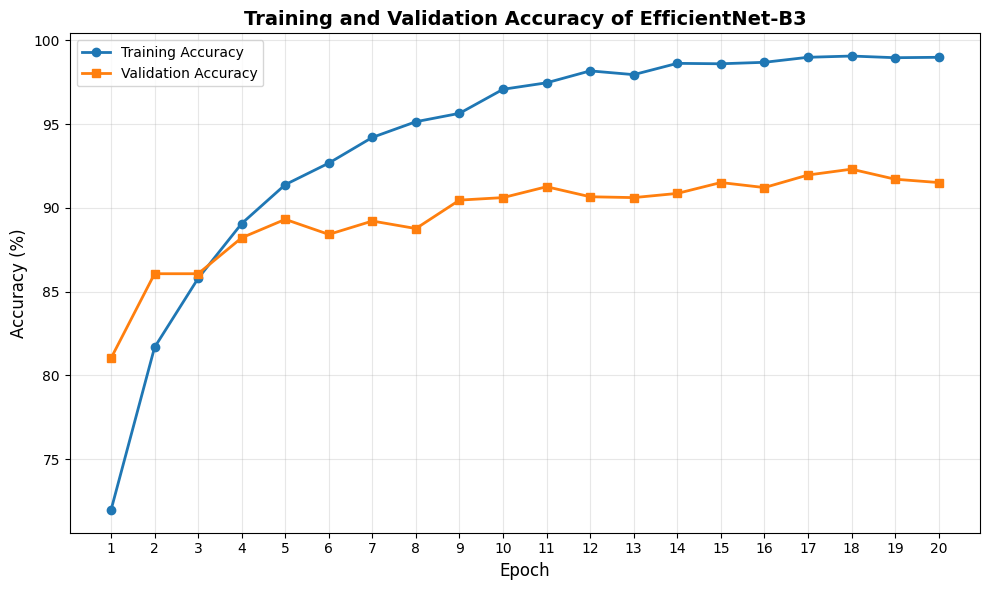

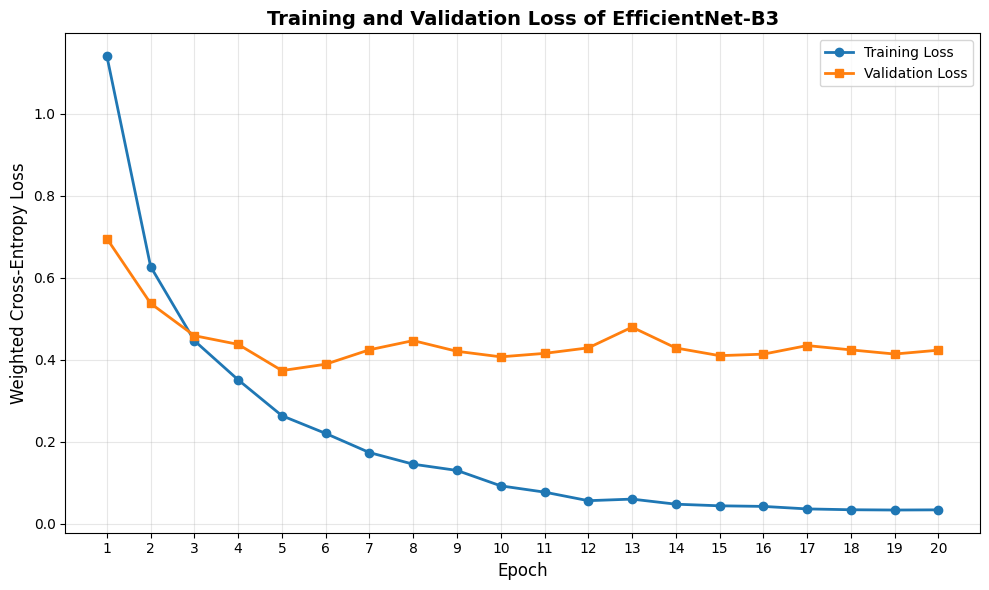

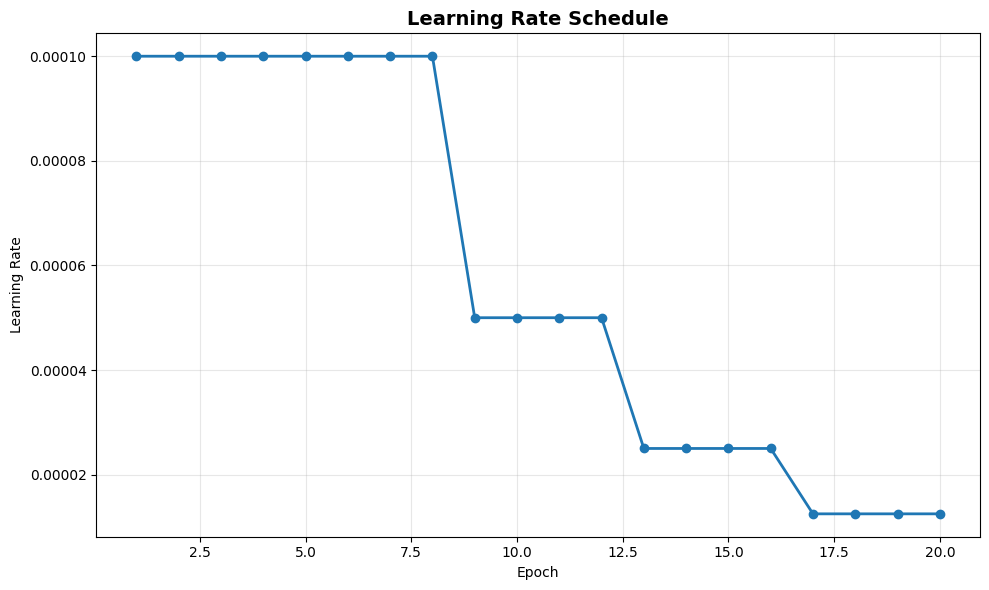

✓ Training graphs generated successfully.


In [ ]:
# ============================================================
# BLOCK 11: TRAINING, VALIDATION AND LEARNING RATE CURVES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# VERIFY TRAINING HISTORY
# ============================================================

if "history" not in globals():
    raise RuntimeError(
        "Training history not found. Run Block 10 first."
    )

num_completed_epochs = len(
    history["train_loss"]
)

epochs_range = np.arange(
    1,
    num_completed_epochs + 1
)

# ============================================================
# CREATE HISTORY DATAFRAME
# ============================================================

history_df = pd.DataFrame({

    "Epoch":
        epochs_range,

    "Training Loss":
        history["train_loss"],

    "Validation Loss":
        history["val_loss"],

    "Training Accuracy (%)":
        np.array(
            history["train_accuracy"]
        ) * 100,

    "Validation Accuracy (%)":
        np.array(
            history["val_accuracy"]
        ) * 100,

    "Learning Rate":
        history["learning_rate"]
})

print("=" * 75)
print("TRAINING HISTORY")
print("=" * 75)

display(
    history_df.round(6)
)

# ============================================================
# FIGURE 1: ACCURACY CURVE
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    epochs_range,
    np.array(
        history["train_accuracy"]
    ) * 100,
    marker="o",
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    np.array(
        history["val_accuracy"]
    ) * 100,
    marker="s",
    linewidth=2,
    label="Validation Accuracy"
)

plt.xlabel(
    "Epoch",
    fontsize=12
)

plt.ylabel(
    "Accuracy (%)",
    fontsize=12
)

plt.title(
    "Training and Validation Accuracy of EfficientNet-B3",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(
    epochs_range
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "03_Training_Validation_Accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# FIGURE 2: LOSS CURVE
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    epochs_range,
    history["train_loss"],
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epochs_range,
    history["val_loss"],
    marker="s",
    linewidth=2,
    label="Validation Loss"
)

plt.xlabel(
    "Epoch",
    fontsize=12
)

plt.ylabel(
    "Weighted Cross-Entropy Loss",
    fontsize=12
)

plt.title(
    "Training and Validation Loss of EfficientNet-B3",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(
    epochs_range
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "04_Training_Validation_Loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# FIGURE 3: LEARNING RATE
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    epochs_range,
    history["learning_rate"],
    marker="o",
    linewidth=2
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Learning Rate"
)

plt.title(
    "Learning Rate Schedule",
    fontsize=14,
    fontweight="bold"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "05_Learning_Rate_Schedule.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "✓ Training graphs generated successfully."
)

In [ ]:
# ============================================================
# BLOCK 12: FINAL MODEL EVALUATION
# ============================================================

import numpy as np
import torch

from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# ============================================================
# SET BEST MODEL TO EVALUATION MODE
# ============================================================

model.eval()

y_true = []
y_pred = []
y_prob = []

print("=" * 75)
print("FINAL EFFICIENTNET-B3 EVALUATION")
print("=" * 75)

# ============================================================
# RUN INFERENCE
# ============================================================

with torch.no_grad():

    for images, labels in tqdm(
        test_loader,
        desc="Evaluating Test/Validation Set"
    ):

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        outputs = model(
            images
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        y_true.extend(
            labels.cpu().numpy()
        )

        y_pred.extend(
            predictions.cpu().numpy()
        )

        y_prob.extend(
            probabilities.cpu().numpy()
        )

# ============================================================
# CONVERT TO NUMPY
# ============================================================

y_true = np.array(
    y_true
)

y_pred = np.array(
    y_pred
)

y_prob = np.array(
    y_prob
)

print(
    "\nTotal Evaluated Images:",
    len(y_true)
)

# ============================================================
# OVERALL ACCURACY
# ============================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

# ============================================================
# WEIGHTED METRICS
# ============================================================

weighted_precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

weighted_recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

# ============================================================
# MACRO METRICS
# Important for imbalanced HAM10000 dataset
# ============================================================

macro_precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

# ============================================================
# MELANOMA RECALL
# ============================================================

mel_idx = CLASS_TO_IDX[
    "mel"
]

melanoma_recall = recall_score(
    (y_true == mel_idx).astype(int),
    (y_pred == mel_idx).astype(int),
    zero_division=0
)

# ============================================================
# DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 75)
print("FINAL EXPERIMENTAL RESULTS")
print("=" * 75)

print(
    f"Overall Accuracy    : "
    f"{accuracy * 100:.2f}%"
)

print("\nWeighted Metrics")

print(
    f"Weighted Precision  : "
    f"{weighted_precision:.4f}"
)

print(
    f"Weighted Recall     : "
    f"{weighted_recall:.4f}"
)

print(
    f"Weighted F1-Score   : "
    f"{weighted_f1:.4f}"
)

print("\nMacro Metrics")

print(
    f"Macro Precision     : "
    f"{macro_precision:.4f}"
)

print(
    f"Macro Recall        : "
    f"{macro_recall:.4f}"
)

print(
    f"Macro F1-Score      : "
    f"{macro_f1:.4f}"
)

print(
    f"\nMelanoma Recall     : "
    f"{melanoma_recall * 100:.2f}%"
)

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 75)
print("CLASSIFICATION REPORT")
print("=" * 75)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            cls.upper()
            for cls in CLASS_NAMES
        ],
        digits=4,
        zero_division=0
    )
)

print(
    "✓ Final evaluation completed."
)

FINAL EFFICIENTNET-B3 EVALUATION


Evaluating Test/Validation Set:   0%|          | 0/63 [00:00<?, ?it/s]


Total Evaluated Images: 2003

FINAL EXPERIMENTAL RESULTS
Overall Accuracy    : 92.36%

Weighted Metrics
Weighted Precision  : 0.9227
Weighted Recall     : 0.9236
Weighted F1-Score   : 0.9230

Macro Metrics
Macro Precision     : 0.8775
Macro Recall        : 0.8736
Macro F1-Score      : 0.8751

Melanoma Recall     : 78.48%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       AKIEC     0.8730    0.8462    0.8594        65
         BCC     0.8932    0.8932    0.8932       103
         BKL     0.8927    0.8318    0.8612       220
          DF     0.8261    0.8261    0.8261        23
         MEL     0.8028    0.7848    0.7937       223
          NV     0.9544    0.9687    0.9615      1341
        VASC     0.9000    0.9643    0.9310        28

    accuracy                         0.9236      2003
   macro avg     0.8775    0.8736    0.8751      2003
weighted avg     0.9227    0.9236    0.9230      2003

✓ Final evaluation completed.


CONFUSION MATRIX
[[  55    4    1    1    2    2    0]
 [   1   92    2    1    1    6    0]
 [   5    3  183    0   13   16    0]
 [   1    0    0   19    0    3    0]
 [   1    2    7    1  175   35    2]
 [   0    2   11    1   27 1299    1]
 [   0    0    1    0    0    0   27]]


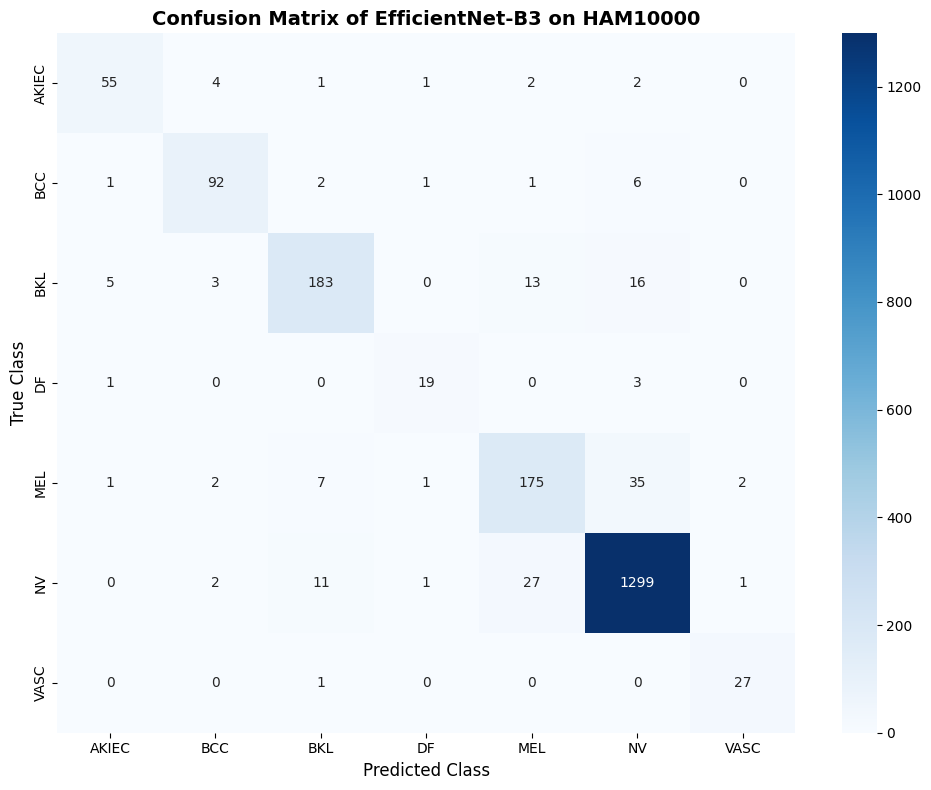

✓ Confusion matrix saved.


In [ ]:
# ============================================================
# BLOCK 13: CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

# ============================================================
# COMPUTE CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

print("=" * 75)
print("CONFUSION MATRIX")
print("=" * 75)

print(
    cm
)

# ============================================================
# PLOT CONFUSION MATRIX
# ============================================================

plt.figure(
    figsize=(10, 8)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        cls.upper()
        for cls in CLASS_NAMES
    ],
    yticklabels=[
        cls.upper()
        for cls in CLASS_NAMES
    ]
)

plt.xlabel(
    "Predicted Class",
    fontsize=12
)

plt.ylabel(
    "True Class",
    fontsize=12
)

plt.title(
    "Confusion Matrix of EfficientNet-B3 on HAM10000",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "06_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "✓ Confusion matrix saved."
)

CLASS-WISE PERFORMANCE


,Class,Full Name,Precision,Recall,F1-Score,Support
0,AKIEC,Actinic Keratoses / Intraepithelial Carcinoma,0.8730,0.8462,0.8594,65
1,BCC,Basal Cell Carcinoma,0.8932,0.8932,0.8932,103
2,BKL,Benign Keratosis-like Lesions,0.8927,0.8318,0.8612,220
3,DF,Dermatofibroma,0.8261,0.8261,0.8261,23
4,MEL,Melanoma,0.8028,0.7848,0.7937,223
5,NV,Melanocytic Nevus,0.9544,0.9687,0.9615,1341
6,VASC,Vascular Lesions,0.9000,0.9643,0.9310,28


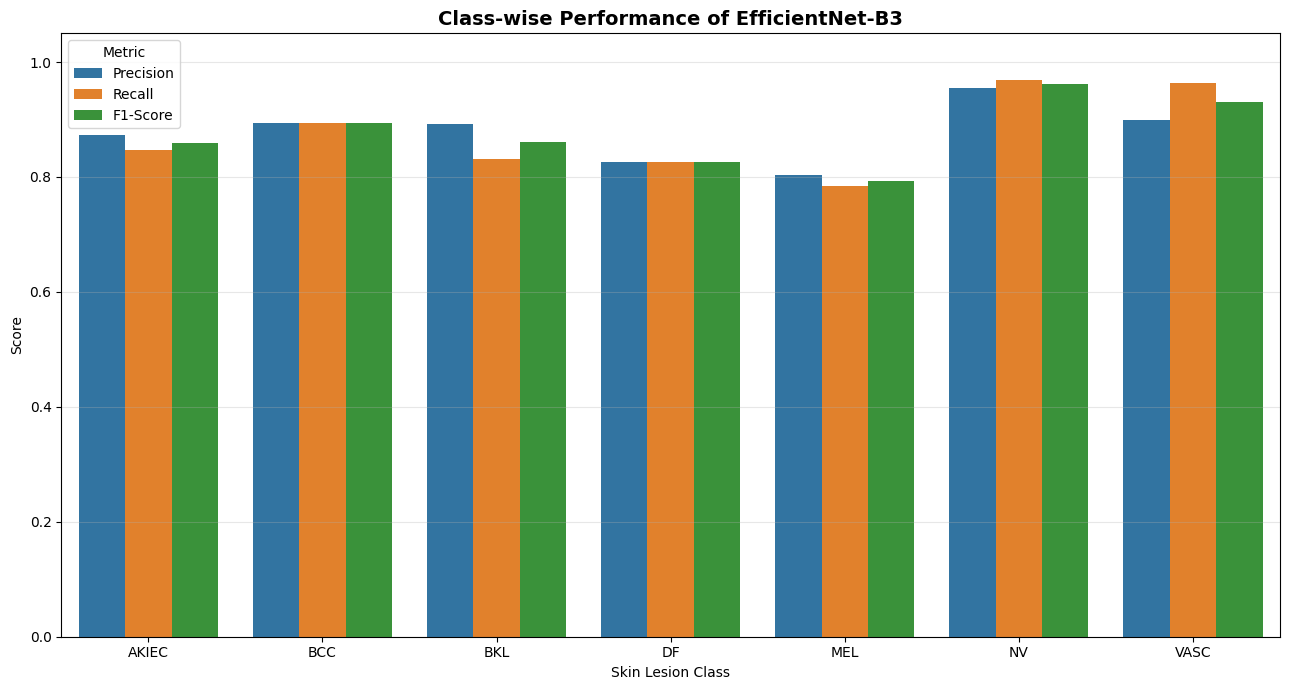

✓ Class-wise performance generated.


In [ ]:
# ============================================================
# BLOCK 14: CLASS-WISE PERFORMANCE METRICS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report

# ============================================================
# GENERATE CLASSIFICATION REPORT
# ============================================================

report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

# ============================================================
# CREATE TABLE
# ============================================================

class_metrics = pd.DataFrame({

    "Class": [
        cls.upper()
        for cls in CLASS_NAMES
    ],

    "Full Name": [
        CLASS_FULL_NAMES[cls]
        for cls in CLASS_NAMES
    ],

    "Precision": [
        report[cls]["precision"]
        for cls in CLASS_NAMES
    ],

    "Recall": [
        report[cls]["recall"]
        for cls in CLASS_NAMES
    ],

    "F1-Score": [
        report[cls]["f1-score"]
        for cls in CLASS_NAMES
    ],

    "Support": [
        int(report[cls]["support"])
        for cls in CLASS_NAMES
    ]
})

print("=" * 75)
print("CLASS-WISE PERFORMANCE")
print("=" * 75)

display(
    class_metrics.round(4)
)

# ============================================================
# SAVE TABLE
# ============================================================

class_metrics.to_csv(
    "Classwise_Performance_Metrics.csv",
    index=False
)

# ============================================================
# PREPARE DATA FOR GRAPH
# ============================================================

plot_metrics = class_metrics[
    [
        "Class",
        "Precision",
        "Recall",
        "F1-Score"
    ]
].melt(
    id_vars="Class",
    var_name="Metric",
    value_name="Score"
)

# ============================================================
# PLOT
# ============================================================

plt.figure(
    figsize=(13, 7)
)

sns.barplot(
    data=plot_metrics,
    x="Class",
    y="Score",
    hue="Metric"
)

plt.ylim(
    0,
    1.05
)

plt.xlabel(
    "Skin Lesion Class"
)

plt.ylabel(
    "Score"
)

plt.title(
    "Class-wise Performance of EfficientNet-B3",
    fontsize=14,
    fontweight="bold"
)

plt.legend(
    title="Metric"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "07_Classwise_Performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "✓ Class-wise performance generated."
)

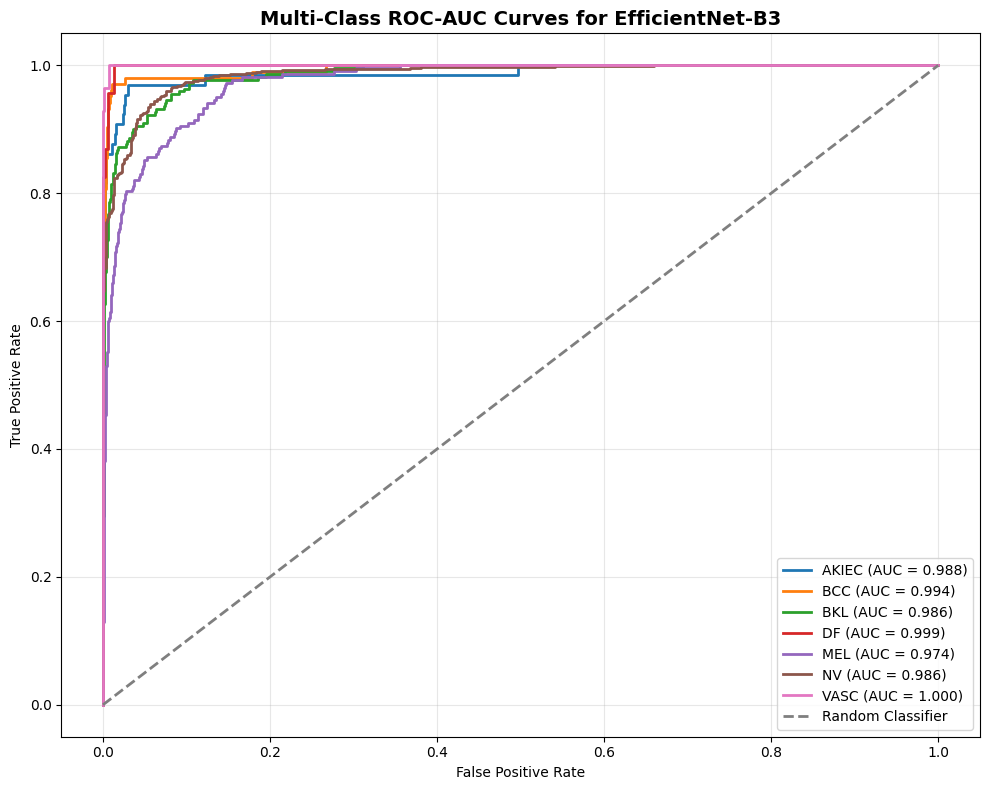


Class-wise ROC-AUC


,Class,ROC-AUC
0,AKIEC,0.9879
1,BCC,0.9942
2,BKL,0.9859
3,DF,0.9989
4,MEL,0.9744
5,NV,0.9864
6,VASC,0.9997


In [ ]:
# ============================================================
# BLOCK 15: MULTI-CLASS ROC-AUC ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize

from sklearn.metrics import (
    roc_curve,
    auc
)

# ============================================================
# BINARIZE TRUE LABELS
# ============================================================

y_true_binary = label_binarize(
    y_true,
    classes=np.arange(
        NUM_CLASSES
    )
)

# ============================================================
# STORE AUC RESULTS
# ============================================================

roc_auc_results = {}

plt.figure(
    figsize=(10, 8)
)

# ============================================================
# ROC CURVE FOR EACH CLASS
# ============================================================

for i, cls in enumerate(
    CLASS_NAMES
):

    fpr, tpr, _ = roc_curve(
        y_true_binary[:, i],
        y_prob[:, i]
    )

    class_auc = auc(
        fpr,
        tpr
    )

    roc_auc_results[
        cls
    ] = class_auc

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=(
            f"{cls.upper()} "
            f"(AUC = {class_auc:.3f})"
        )
    )

# ============================================================
# RANDOM CLASSIFIER LINE
# ============================================================

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random Classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Multi-Class ROC-AUC Curves for EfficientNet-B3",
    fontsize=14,
    fontweight="bold"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "08_ROC_AUC_Curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# DISPLAY AUC TABLE
# ============================================================

roc_auc_df = pd.DataFrame({

    "Class": [
        cls.upper()
        for cls in CLASS_NAMES
    ],

    "ROC-AUC": [
        roc_auc_results[cls]
        for cls in CLASS_NAMES
    ]
})

print("\nClass-wise ROC-AUC")

display(
    roc_auc_df.round(4)
)

roc_auc_df.to_csv(
    "ROC_AUC_Results.csv",
    index=False
)

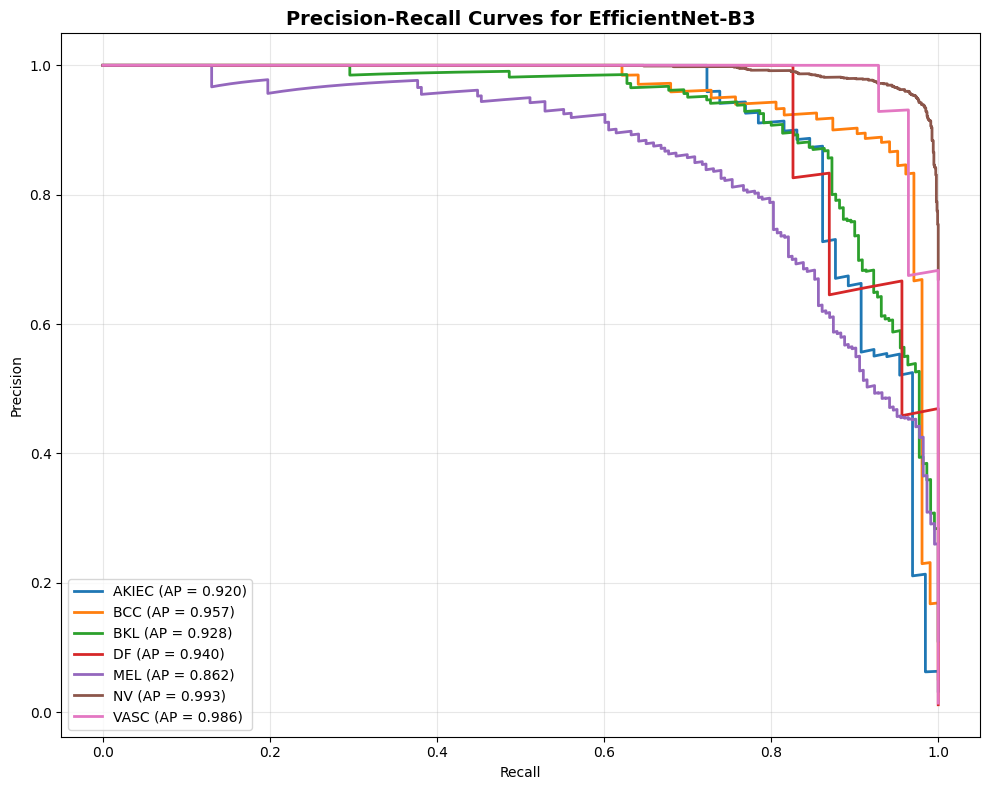


Class-wise Average Precision


,Class,Average Precision
0,AKIEC,0.9200
1,BCC,0.9569
2,BKL,0.9280
3,DF,0.9402
4,MEL,0.8618
5,NV,0.9933
6,VASC,0.9862


In [ ]:
# ============================================================
# BLOCK 16: PRECISION-RECALL CURVES
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

average_precision_results = {}

plt.figure(
    figsize=(10, 8)
)

# ============================================================
# PRECISION-RECALL CURVE FOR EACH CLASS
# ============================================================

for i, cls in enumerate(
    CLASS_NAMES
):

    precision_values, recall_values, _ = (
        precision_recall_curve(
            y_true_binary[:, i],
            y_prob[:, i]
        )
    )

    ap_score = average_precision_score(
        y_true_binary[:, i],
        y_prob[:, i]
    )

    average_precision_results[
        cls
    ] = ap_score

    plt.plot(
        recall_values,
        precision_values,
        linewidth=2,
        label=(
            f"{cls.upper()} "
            f"(AP = {ap_score:.3f})"
        )
    )

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision-Recall Curves for EfficientNet-B3",
    fontsize=14,
    fontweight="bold"
)

plt.legend(
    loc="lower left"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "09_Precision_Recall_Curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# DISPLAY AVERAGE PRECISION TABLE
# ============================================================

ap_df = pd.DataFrame({

    "Class": [
        cls.upper()
        for cls in CLASS_NAMES
    ],

    "Average Precision": [
        average_precision_results[cls]
        for cls in CLASS_NAMES
    ]
})

print(
    "\nClass-wise Average Precision"
)

display(
    ap_df.round(4)
)

ap_df.to_csv(
    "Average_Precision_Results.csv",
    index=False
)

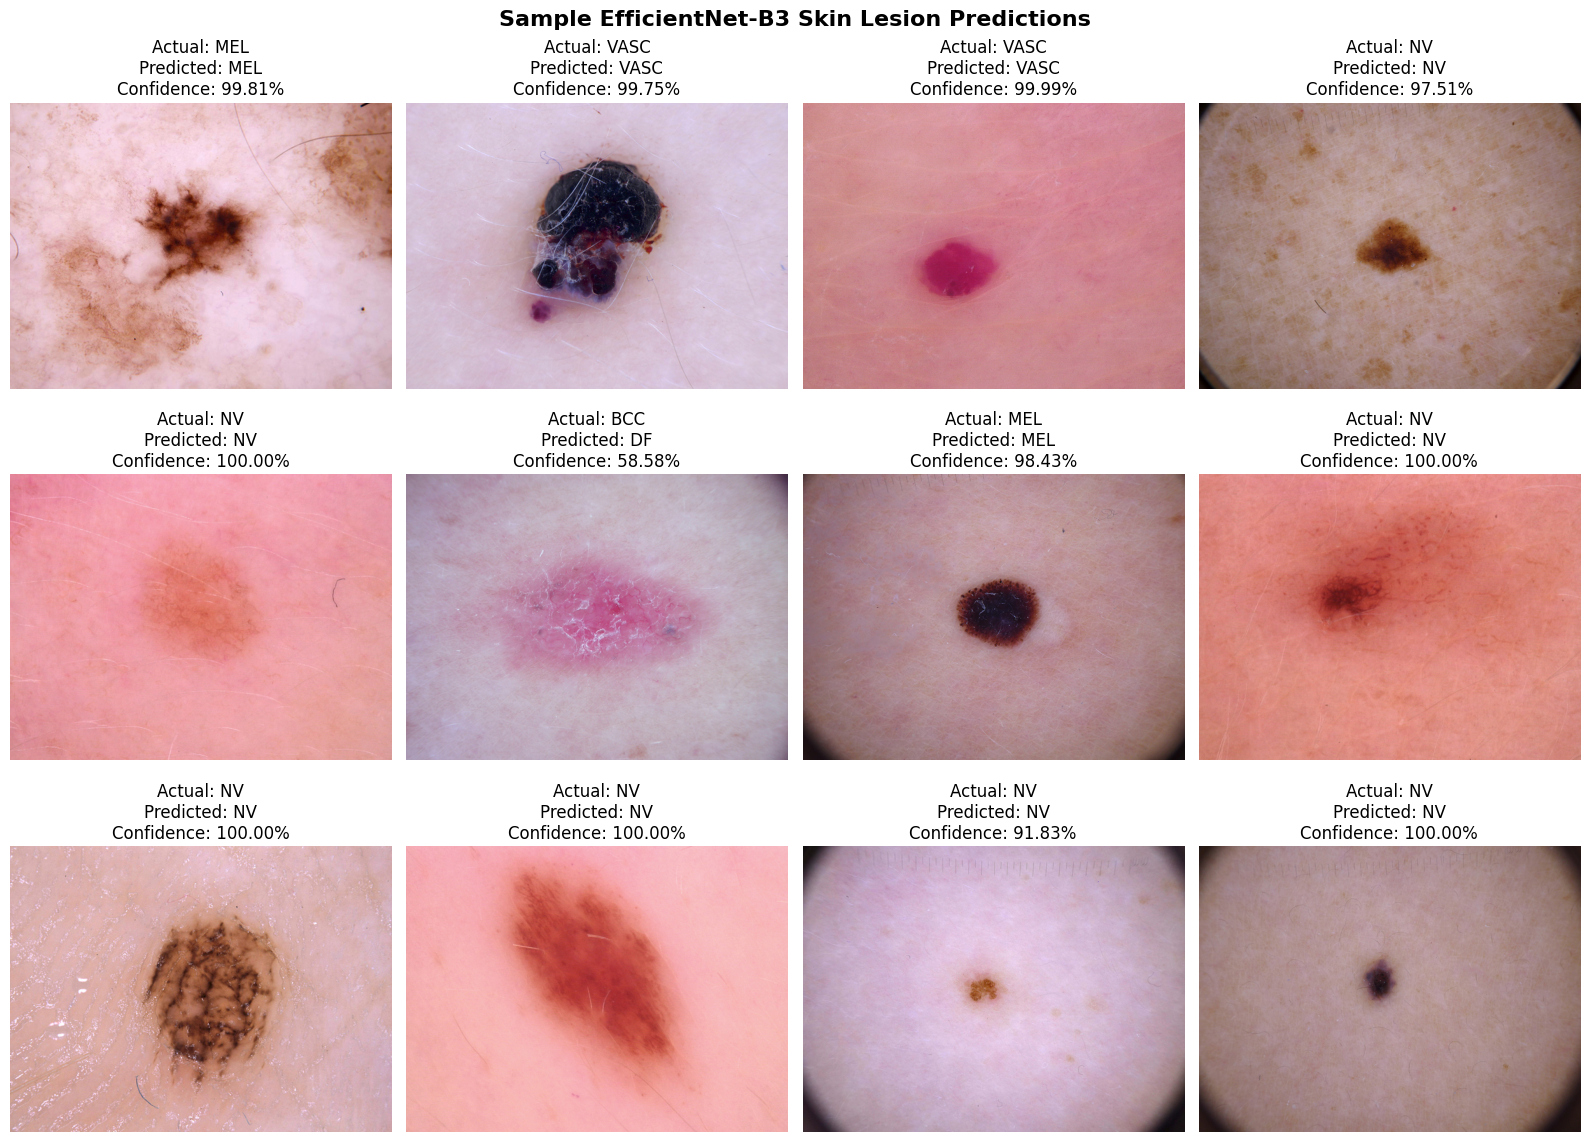

Correct Predictions  : 1850
Incorrect Predictions: 153
Total Predictions    : 2003


In [ ]:
# ============================================================
# BLOCK 17: SAMPLE MODEL PREDICTIONS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

# ============================================================
# RANDOM SAMPLE PREDICTIONS
# ============================================================

num_samples = min(
    12,
    len(test_df)
)

np.random.seed(
    SEED
)

sample_indices = np.random.choice(
    len(test_df),
    size=num_samples,
    replace=False
)

fig, axes = plt.subplots(
    3,
    4,
    figsize=(16, 12)
)

axes = axes.flatten()

for ax, idx in zip(
    axes,
    sample_indices
):

    image_path = test_df.iloc[
        idx
    ]["image_path"]

    image = Image.open(
        image_path
    ).convert(
        "RGB"
    )

    true_idx = int(
        y_true[idx]
    )

    pred_idx = int(
        y_pred[idx]
    )

    true_class = CLASS_NAMES[
        true_idx
    ].upper()

    predicted_class = CLASS_NAMES[
        pred_idx
    ].upper()

    confidence = (
        y_prob[
            idx,
            pred_idx
        ]
        * 100
    )

    ax.imshow(
        image
    )

    ax.set_title(
        f"Actual: {true_class}\n"
        f"Predicted: {predicted_class}\n"
        f"Confidence: {confidence:.2f}%"
    )

    ax.axis(
        "off"
    )

plt.suptitle(
    "Sample EfficientNet-B3 Skin Lesion Predictions",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "10_Sample_Predictions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# NUMBER OF CORRECT / INCORRECT PREDICTIONS
# ============================================================

correct_count = np.sum(
    y_true == y_pred
)

incorrect_count = np.sum(
    y_true != y_pred
)

print(
    "Correct Predictions  :",
    correct_count
)

print(
    "Incorrect Predictions:",
    incorrect_count
)

print(
    "Total Predictions    :",
    len(y_true)
)

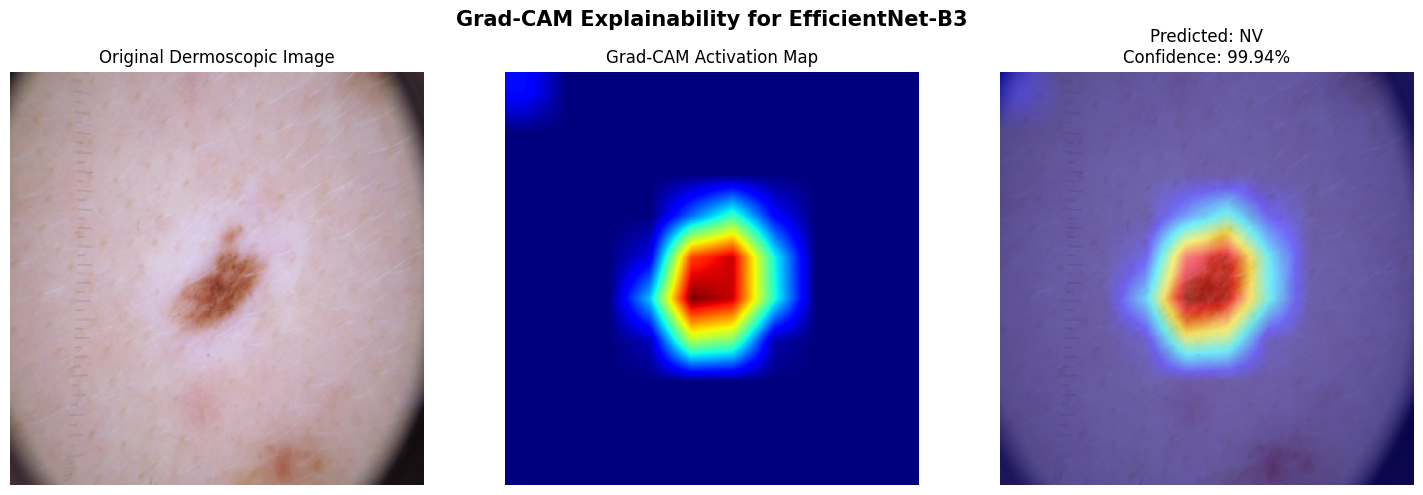


Grad-CAM Result
Predicted Class: NV
Confidence: 99.94%
✓ Grad-CAM generated successfully.


In [ ]:
# ============================================================
# BLOCK 18: GRAD-CAM EXPLAINABILITY
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

from PIL import Image

from pytorch_grad_cam import GradCAM

from pytorch_grad_cam.utils.model_targets import (
    ClassifierOutputTarget
)

from pytorch_grad_cam.utils.image import (
    show_cam_on_image
)

# ============================================================
# SET MODEL TO EVALUATION MODE
# ============================================================

model.eval()

# ============================================================
# TARGET LAYER
#
# Last convolutional feature block of EfficientNet-B3
# ============================================================

target_layers = [
    model.features[-1]
]

# ============================================================
# INITIALIZE GRAD-CAM
# ============================================================

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

# ============================================================
# GRAD-CAM FUNCTION
# ============================================================

def generate_gradcam(
    image_path,
    save_path=None
):

    model.eval()

    # ========================================================
    # LOAD ORIGINAL IMAGE
    # ========================================================

    original_image = Image.open(
        image_path
    ).convert(
        "RGB"
    )

    # ========================================================
    # RESIZE FOR VISUALIZATION
    # ========================================================

    resized_image = original_image.resize(
        (
            IMG_SIZE,
            IMG_SIZE
        )
    )

    rgb_image = np.array(
        resized_image
    ).astype(
        np.float32
    )

    rgb_image = (
        rgb_image
        / 255.0
    )

    # ========================================================
    # PREPROCESS FOR MODEL
    # ========================================================

    input_tensor = test_transform(
        original_image
    ).unsqueeze(
        0
    ).to(
        DEVICE
    )

    # ========================================================
    # MODEL PREDICTION
    # ========================================================

    with torch.no_grad():

        outputs = model(
            input_tensor
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predicted_idx = int(
            torch.argmax(
                probabilities,
                dim=1
            ).item()
        )

        confidence = float(
            probabilities[
                0,
                predicted_idx
            ].item()
        )

    # ========================================================
    # GRAD-CAM TARGET
    # ========================================================

    targets = [
        ClassifierOutputTarget(
            predicted_idx
        )
    ]

    # ========================================================
    # GENERATE CAM
    # ========================================================

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    # ========================================================
    # CREATE OVERLAY
    # ========================================================

    cam_visualization = show_cam_on_image(
        rgb_image,
        grayscale_cam,
        use_rgb=True
    )

    # ========================================================
    # DISPLAY
    # ========================================================

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )

    axes[0].imshow(
        resized_image
    )

    axes[0].set_title(
        "Original Dermoscopic Image"
    )

    axes[0].axis(
        "off"
    )

    axes[1].imshow(
        grayscale_cam,
        cmap="jet"
    )

    axes[1].set_title(
        "Grad-CAM Activation Map"
    )

    axes[1].axis(
        "off"
    )

    axes[2].imshow(
        cam_visualization
    )

    axes[2].set_title(
        f"Predicted: "
        f"{CLASS_NAMES[predicted_idx].upper()}\n"
        f"Confidence: "
        f"{confidence * 100:.2f}%"
    )

    axes[2].axis(
        "off"
    )

    plt.suptitle(
        "Grad-CAM Explainability for EfficientNet-B3",
        fontsize=15,
        fontweight="bold"
    )

    plt.tight_layout()

    if save_path is not None:

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

    return {
        "predicted_index":
            predicted_idx,

        "predicted_class":
            CLASS_NAMES[
                predicted_idx
            ],

        "confidence":
            confidence,

        "cam":
            cam_visualization
    }


# ============================================================
# TEST GRAD-CAM ON ONE DATASET IMAGE
# ============================================================

sample_path = test_df.iloc[
    0
]["image_path"]

gradcam_result = generate_gradcam(
    sample_path,
    save_path="11_GradCAM_Example.png"
)

print("\nGrad-CAM Result")

print(
    "Predicted Class:",
    gradcam_result[
        "predicted_class"
    ].upper()
)

print(
    "Confidence:",
    f"{gradcam_result['confidence'] * 100:.2f}%"
)

print(
    "✓ Grad-CAM generated successfully."
)

UPLOAD A DERMOSCOPIC SKIN LESION IMAGE

Select a JPG, JPEG, or PNG dermoscopic image.


Saving skin cancer.avif to skin cancer.avif

Processing: skin cancer.avif


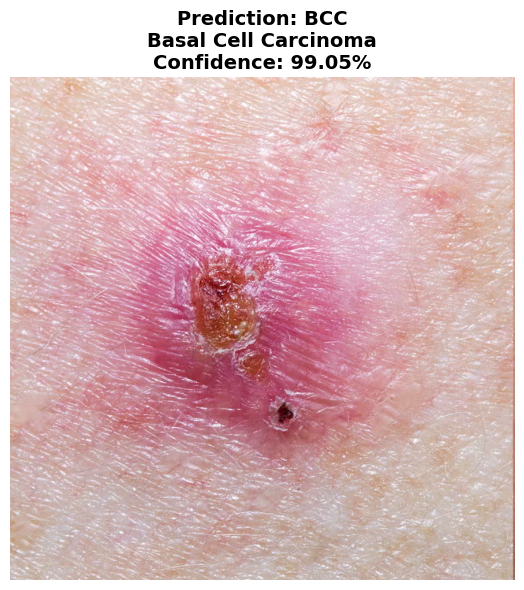


SKIN LESION CLASSIFICATION RESULT
Predicted Class     : BCC
Predicted Diagnosis : Basal Cell Carcinoma
Confidence          : 99.05%

Prediction Probability Distribution


,Class,Diagnosis,Probability (%)
0,BCC,Basal Cell Carcinoma,99.05%
1,MEL,Melanoma,0.41%
2,VASC,Vascular Lesions,0.33%
3,BKL,Benign Keratosis-like Lesions,0.11%
4,NV,Melanocytic Nevus,0.04%
5,AKIEC,Actinic Keratoses / Intraepithelial Carcinoma,0.03%
6,DF,Dermatofibroma,0.02%


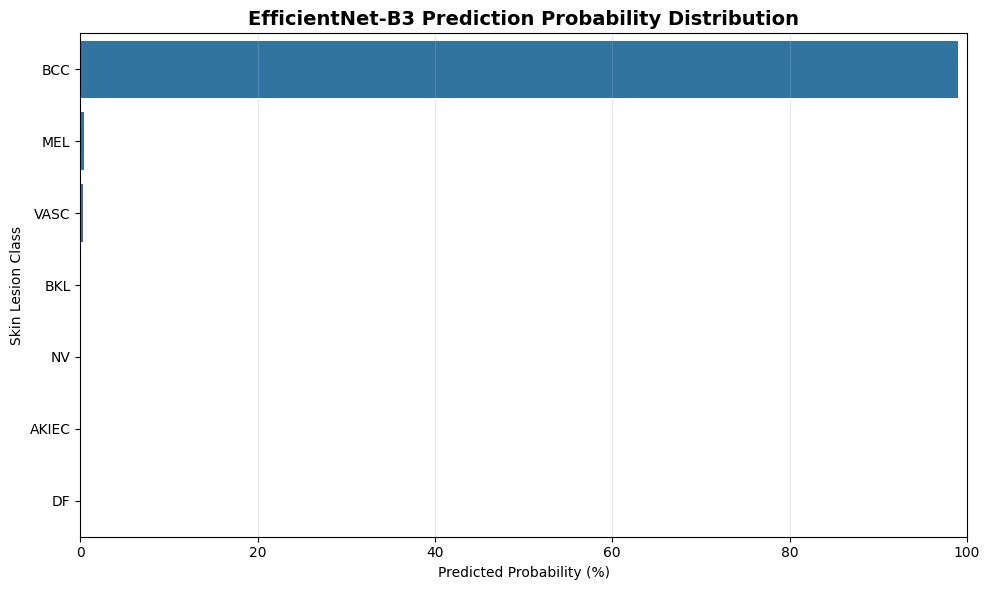


TOP-3 MODEL PREDICTIONS
---------------------------------------------------------------------------
1. BCC - Basal Cell Carcinoma (99.05%)
2. MEL - Melanoma (0.41%)
3. VASC - Vascular Lesions (0.33%)

Generating Grad-CAM explainability...


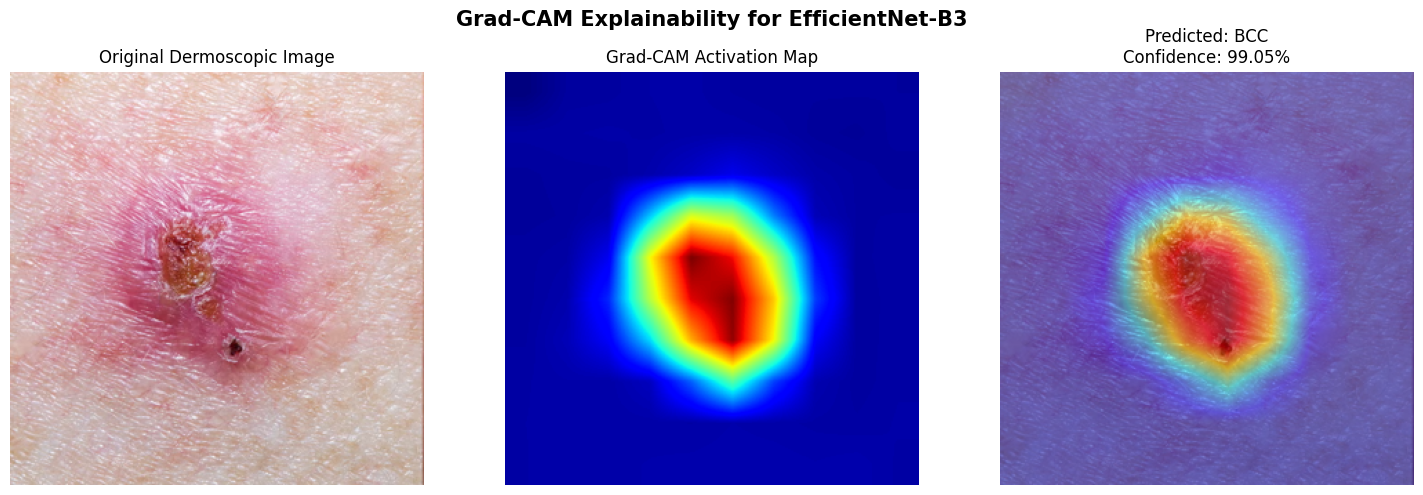

In [ ]:
# ============================================================
# BLOCK 19: UPLOAD NEW IMAGE AND PREDICT
# ============================================================

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from google.colab import files


# ============================================================
# PREDICTION FUNCTION
# ============================================================

def predict_uploaded_image(
    image_path
):

    model.eval()

    # ========================================================
    # LOAD IMAGE
    # ========================================================

    original_image = Image.open(
        image_path
    ).convert(
        "RGB"
    )

    # ========================================================
    # PREPROCESS IMAGE
    # ========================================================

    input_tensor = test_transform(
        original_image
    ).unsqueeze(
        0
    ).to(
        DEVICE
    )

    # ========================================================
    # MODEL INFERENCE
    # ========================================================

    with torch.no_grad():

        outputs = model(
            input_tensor
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )[0].cpu().numpy()

    # ========================================================
    # PREDICTED CLASS
    # ========================================================

    predicted_idx = int(
        np.argmax(
            probabilities
        )
    )

    predicted_code = CLASS_NAMES[
        predicted_idx
    ]

    predicted_diagnosis = CLASS_FULL_NAMES[
        predicted_code
    ]

    confidence = float(
        probabilities[
            predicted_idx
        ]
        * 100
    )

    # ========================================================
    # DISPLAY UPLOADED IMAGE
    # ========================================================

    plt.figure(
        figsize=(7, 6)
    )

    plt.imshow(
        original_image
    )

    plt.axis(
        "off"
    )

    plt.title(
        f"Prediction: "
        f"{predicted_code.upper()}\n"
        f"{predicted_diagnosis}\n"
        f"Confidence: "
        f"{confidence:.2f}%",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()

    plt.show()

    # ========================================================
    # PRINT RESULT
    # ========================================================

    print("\n" + "=" * 75)
    print("SKIN LESION CLASSIFICATION RESULT")
    print("=" * 75)

    print(
        f"Predicted Class     : "
        f"{predicted_code.upper()}"
    )

    print(
        f"Predicted Diagnosis : "
        f"{predicted_diagnosis}"
    )

    print(
        f"Confidence          : "
        f"{confidence:.2f}%"
    )

    print("=" * 75)

    # ========================================================
    # CREATE PROBABILITY TABLE
    # ========================================================

    probability_df = pd.DataFrame({

        "Class": [
            cls.upper()
            for cls in CLASS_NAMES
        ],

        "Diagnosis": [
            CLASS_FULL_NAMES[cls]
            for cls in CLASS_NAMES
        ],

        "Probability (%)":
            probabilities * 100
    })

    probability_df = (
        probability_df
        .sort_values(
            by="Probability (%)",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

    print(
        "\nPrediction Probability Distribution"
    )

    display(
        probability_df.style.format({
            "Probability (%)":
                "{:.2f}%"
        })
    )

    # ========================================================
    # PROBABILITY GRAPH
    # ========================================================

    plt.figure(
        figsize=(10, 6)
    )

    sns.barplot(
        data=probability_df,
        x="Probability (%)",
        y="Class"
    )

    plt.xlabel(
        "Predicted Probability (%)"
    )

    plt.ylabel(
        "Skin Lesion Class"
    )

    plt.title(
        "EfficientNet-B3 Prediction Probability Distribution",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlim(
        0,
        100
    )

    plt.grid(
        axis="x",
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

    # ========================================================
    # TOP-3 PREDICTIONS
    # ========================================================

    print(
        "\nTOP-3 MODEL PREDICTIONS"
    )

    print("-" * 75)

    for rank in range(
        min(
            3,
            len(probability_df)
        )
    ):

        row = probability_df.iloc[
            rank
        ]

        print(
            f"{rank + 1}. "
            f"{row['Class']} - "
            f"{row['Diagnosis']} "
            f"({row['Probability (%)']:.2f}%)"
        )

    # ========================================================
    # GRAD-CAM EXPLAINABILITY
    # ========================================================

    print(
        "\nGenerating Grad-CAM explainability..."
    )

    gradcam_result = generate_gradcam(
        image_path
    )

    # ========================================================
    # RETURN RESULTS
    # ========================================================

    return {

        "predicted_class":
            predicted_code,

        "diagnosis":
            predicted_diagnosis,

        "confidence":
            confidence,

        "probabilities":
            probability_df
    }


# ============================================================
# IMAGE UPLOAD
# ============================================================

print("=" * 75)
print("UPLOAD A DERMOSCOPIC SKIN LESION IMAGE")
print("=" * 75)

print(
    "\nSelect a JPG, JPEG, or PNG dermoscopic image."
)

uploaded = files.upload()


# ============================================================
# PROCESS EACH UPLOADED IMAGE
# ============================================================

for filename in uploaded.keys():

    print(
        "\nProcessing:",
        filename
    )

    try:

        final_result = predict_uploaded_image(
            filename
        )

    except Exception as e:

        print(
            f"Error processing {filename}:"
        )

        print(
            str(e)
        )